# Capstone Project: Introduction to Machine Learning (2026)
## Course Cancellation Prediction – Nova Academy

**Submitted by:** Yahli Efrati & Doron Bachar  
**Group Number:** 31  


---

### Project Description & Business Objective
Nova Academy provides advanced B2B technology training, requiring significant upfront investments in cloud labs, catering, and logistics. This project develops a machine learning pipeline to predict the probability of a course registration being canceled (`Dropped_Course`) using historical CRM data. 

The primary business objective is to minimize financial losses resulting from over-provisioning and empty seats, enabling proactive resource optimization and capacity management.

---

In [236]:
# ==============================================================================
# STEP 1: LIBRARY IMPORTS & ENVIRONMENT SETUP
# ==============================================================================

# Core Data Science Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Technical & Mathematical Utilities
import math
from typing import List, Dict, Tuple, Optional

# Machine Learning & Preprocessing (Scikit-Learn)
# Note: Preparing imports for future handling of missing values & evaluations
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# Global Visual Settings for Scannability and Clarity
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Verification Message
print("✓ Environment successfully configured. All libraries imported.")

✓ Environment successfully configured. All libraries imported.


## Part A: EDA - Data Understanding / Exploration

In this section, we load the dataset and perform an initial inspection to understand its structure, dimensions, data types,distributions and  missing values.

In [237]:
# Load the training dataset
df_train = pd.read_csv(r'C:\DF_in_LocalDisk\Train_Data.csv')

# Display the first 5 rows
df_train.head()

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Practical_Hours,Theory_Hours,Registration_Days_Before,Origin_Country,Catering_Package,...,Enrollment_Type,Lanyard_Color,Client_Category,Submission_Source,Returning_Client,Agent_ID,Company_ID,Payment_Terms,Daily_Tuition_Cost,Dropped_Course
0,13766,2,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
1,78660,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
2,51396,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
3,34000,2,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
4,69025,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,...,General Admission,Orange,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0


In [238]:
# 1. Get a summary of columns, data types, and non-null counts
print("--- Dataframe Info ---")
df_train.info()
 
print("\n" + "="*50 + "\n")
 
# 2. Get statistical summary for numerical features
print("--- Statistical Summary ---")
df_train.describe()

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63464 entries, 0 to 63463
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Client_ID                    63464 non-null  int64  
 1   Professionals_Count          63464 non-null  int64  
 2   Students_Count               63460 non-null  float64
 3   Observers_Count              63464 non-null  int64  
 4   Course_Start_Date            63464 non-null  object 
 5   Practical_Hours              63464 non-null  int64  
 6   Theory_Hours                 63464 non-null  int64  
 7   Registration_Days_Before     60798 non-null  float64
 8   Origin_Country               62907 non-null  object 
 9   Catering_Package             63057 non-null  object 
 10  Welcome_Gift_Type            63464 non-null  object 
 11  Requested_Lab_Config         61728 non-null  object 
 12  Assigned_Lab_Config          63464 non-null  object

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Practical_Hours,Theory_Hours,Registration_Days_Before,Prev_Course_Dropouts,Prev_Course_Attended,Pre_Course_Supports_Tickets,Physical_Course_Kits,Waiting_List_Days,Registration_Changes,Returning_Client,Agent_ID,Company_ID,Daily_Tuition_Cost,Dropped_Course
count,63464.000000,63464.000000,63460.000000,63464.000000,63464.000000,63464.000000,60798.000000,63464.000000,63464.000000,63464.000000,62424.000000,63464.000000,63464.000000,63464.000000,52291.000000,3120.000000,63385.000000,63464.000000
mean,39761.752616,1.835214,8.751718,0.005326,6.609054,2.164392,102.894470,0.095991,0.122967,0.513330,0.026224,3.983676,0.180039,0.027133,197.834752,5119.021474,98.847963,0.414392
std,22878.980699,0.508607,294.238584,0.089662,215.502929,1.469854,109.178824,0.448526,1.535201,0.763563,0.160202,23.195495,0.592577,0.162474,47.393068,70.106299,41.855391,0.492621
min,1.000000,0.000000,0.000000,0.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,5002.000000,0.000000,0.000000
25%,19959.750000,2.000000,0.000000,0.000000,0.000000,1.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5035.000000,75.000000,0.000000
50%,39819.500000,2.000000,0.000000,0.000000,1.000000,2.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5146.000000,94.500000,0.000000
75%,59570.250000,2.000000,0.000000,0.000000,1.000000,3.000000,150.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,218.000000,5181.000000,117.000000,1.000000
max,79330.000000,4.000000,9999.000000,10.000000,10000.000000,41.000000,629.000000,21.000000,61.000000,5.000000,3.000000,391.000000,21.000000,1.000000,322.000000,5206.000000,5400.000000,1.000000


### Target Variable & Initial Outlier Detection
To establish a solid "Data Story," we first analyze the distribution of our target variable (`Dropped_Course`) to check for class imbalance. Following this, we visually inspect key numerical features that exhibited extreme values during the statistical summary phase (`df.describe()`), specifically targeting `Students_Count` and `Practical_Hours`.

* **Target Class Balance:** Understanding whether the dataset is skewed toward one class.
* **Anomalies & Placeholders:** Identifying non-logical values (e.g., negative hours) or system placeholders (e.g., 9999).

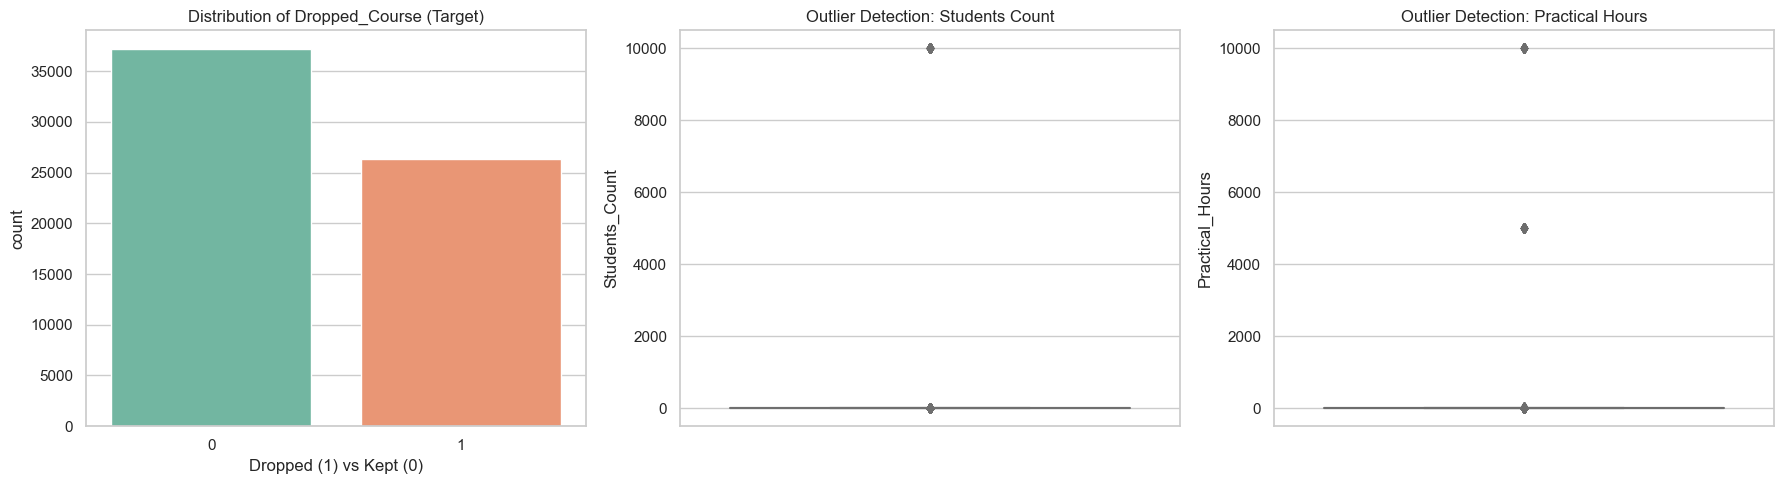

In [239]:
# Create a grid of subplots for initial visual analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Variable Distribution
sns.countplot(data=df_train, x='Dropped_Course', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of Dropped_Course (Target)')
axes[0].set_xlabel('Dropped (1) vs Kept (0)')

# 2. Boxplot to visualize Students_Count Outliers
sns.boxplot(data=df_train, y='Students_Count', ax=axes[1], color='skyblue')
axes[1].set_title('Outlier Detection: Students Count')

# 3. Boxplot to visualize Practical_Hours Outliers
sns.boxplot(data=df_train, y='Practical_Hours', ax=axes[2], color='salmon')
axes[2].set_title('Outlier Detection: Practical Hours')

plt.tight_layout()
plt.show()

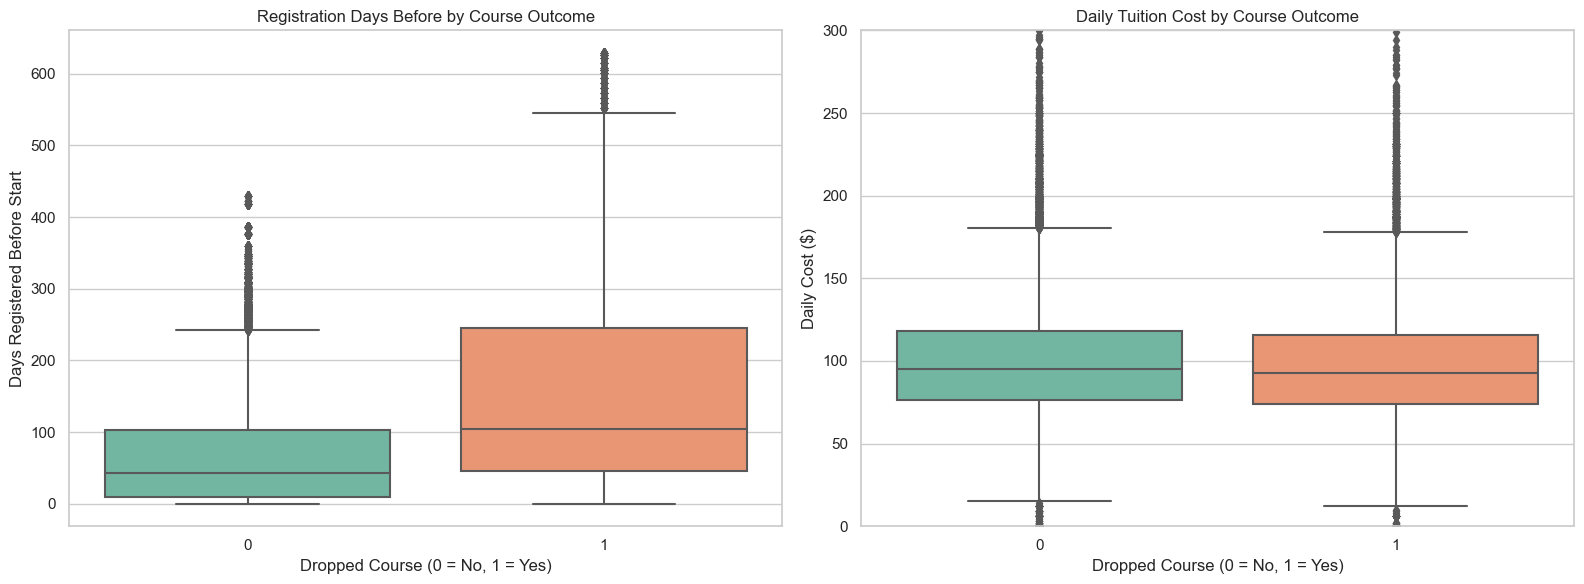

In [240]:
# Create a split boxplot to analyze features against the target variable
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Registration Days Before split by Dropped_Course
sns.boxplot(data=df_train, x='Dropped_Course', y='Registration_Days_Before', ax=axes[0], palette='Set2')
axes[0].set_title('Registration Days Before by Course Outcome')
axes[0].set_xlabel('Dropped Course (0 = No, 1 = Yes)')
axes[0].set_ylabel('Days Registered Before Start')

# Graph 2: Daily Tuition Cost split by Dropped_Course (Limiting y-axis to focus on the bulk of data)
sns.boxplot(data=df_train, x='Dropped_Course', y='Daily_Tuition_Cost', ax=axes[1], palette='Set2')
axes[1].set_title('Daily Tuition Cost by Course Outcome')
axes[1].set_xlabel('Dropped Course (0 = No, 1 = Yes)')
axes[1].set_ylabel('Daily Cost ($)')
axes[1].set_ylim(0, 300) # limiting to 300 to clear out the 5400 outlier and see the boxes clearly

plt.tight_layout()
plt.show()

#### Insights from Bivariate Boxplot Analysis:

1. **Registration Days Before vs. Course Outcome (Key Discovery):**
   * **Observation:** The plot reveals a strong visual discrepancy between the two groups. The median registration time for clients who eventually canceled (`Dropped_Course = 1`) is substantially higher than for those who attended (`Dropped_Course = 0`). The 75th percentile for the canceled group stretches beyond 250 days, while the non-canceled group is heavily concentrated below 100 days.
   * **Business Logic (The Data Story):** This indicates that **early bookers are far more likely to cancel**. From a business perspective, when an organization reserves a course many months in advance, their internal projects, budget allocations, or training needs are more prone to shift, leading to a cancellation. Conversely, short-notice registrations represent immediate corporate needs and are highly stable.
   * **Feature Engineering Value:** `Registration_Days_Before` is highly likely to be one of the most predictive continuous features for our tree-based models (XGBoost).

2. **Daily Tuition Cost vs. Course Outcome:**
   * **Observation:** The distribution of `Daily_Tuition_Cost` looks remarkably similar across both classes. The medians (around $95), IQRs, and ranges are nearly identical after filtering out the extreme system outliers.
   * **Business Logic:** This suggests that the cost of the training alone does not act as a primary driver for cancellations. Whether a course is cheap or expensive, the cancellation behavior remains relatively uniform.

### Correlation Analysis & Feature Interactions
To prevent multicollinearity and understand the linear relationships within our dataset, we compute the Pearson correlation matrix for key numerical features. We then isolate and visualize how each individual feature correlates directly with our target variable (`Dropped_Course`). 

This matrix will provide foundational hints for Feature Selection and Dimensionality Reduction in the next phases.

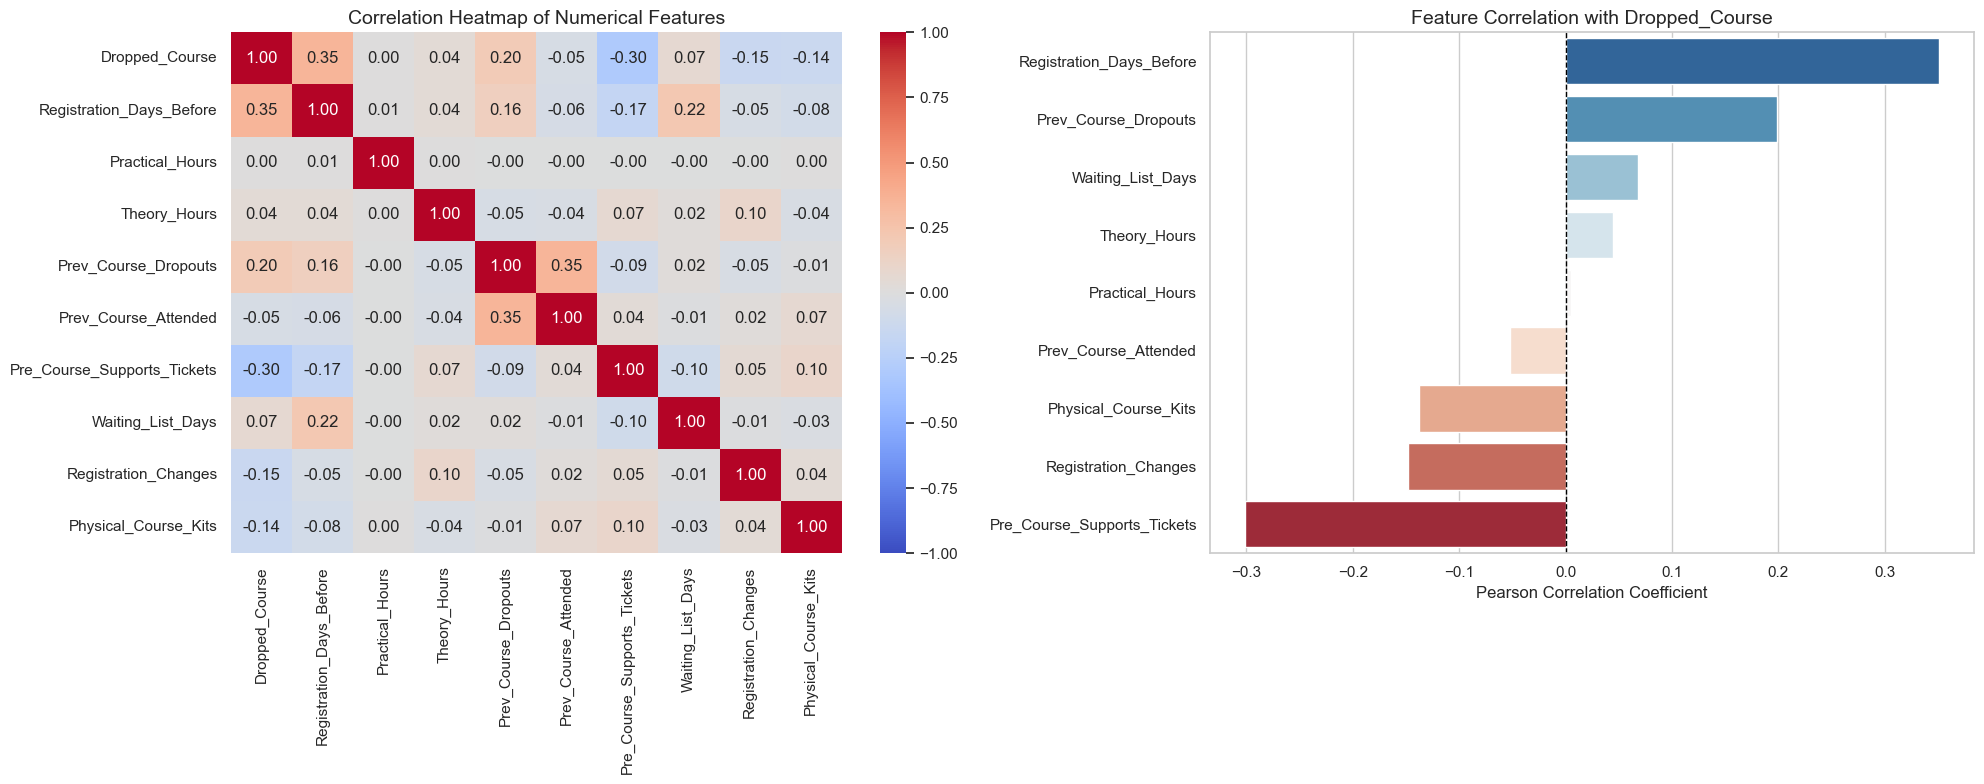

In [241]:
# Select key numerical features for correlation analysis
# (Excluding IDs and heavily distorted features for a cleaner initial look)
corr_features = [
    'Dropped_Course', 'Registration_Days_Before', 'Practical_Hours', 
    'Theory_Hours', 'Prev_Course_Dropouts', 'Prev_Course_Attended', 
    'Pre_Course_Supports_Tickets', 'Waiting_List_Days', 'Registration_Changes',
    'Physical_Course_Kits'
]

# Calculate the Pearson correlation matrix
corr_matrix = df_train[corr_features].corr()

# Set up the matplotlib figure for two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0], cbar=True)
axes[0].set_title('Correlation Heatmap of Numerical Features', fontsize=14)

# 2. Direct Correlation with Target (Sorted)
target_corr = corr_matrix['Dropped_Course'].drop('Dropped_Course').sort_values(ascending=False)
sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette='RdBu_r')
axes[1].set_title('Feature Correlation with Dropped_Course', fontsize=14)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

#### Insights from Correlation Analysis:

1. **Pre-Course Support Tickets vs. Cancellations (Critical Discovery):**
   * **Observation:** `Pre_Course_Supports_Tickets` exhibits a notable negative Pearson correlation of **-0.30** with `Dropped_Course`. 
   * **Business Logic:** Counter-intuitively, a higher volume of support tickets before the course starts strongly aligns with a *lower* probability of cancellation. This indicates that clients who actively engage with customer support or IT configuration requests are highly invested in the upcoming training. Their proactive problem-solving reflects strong intent to attend, while silent clients are far more volatile.

2. **Historical Behavior Consistency (`Prev_Course_Dropouts` = +0.20):**
   * **Observation:** There is a positive correlation between past dropouts and current course cancellations. 
   * **Business Logic:** Organizations that have a history of canceling Nova Academy courses in the past are statistically more prone to repeat this behavior ("serial cancelers"). This provides a strong behavioral anchor for our machine learning model.

3. **Registration Changes (`Registration_Changes` = -0.15):**
   * **Observation:** More modifications to the booking details correlate with fewer cancellations. 
   * **Business Logic:** Making changes to the registration implies that the client is actively updating logistics, catering, or seat counts to match their evolving business constraints, rather than completely abandoning the contract.

### Correlation analysis for `Returning_Client`

Pearson Correlation between 'Returning_Client' and 'Dropped_Course': -0.0592



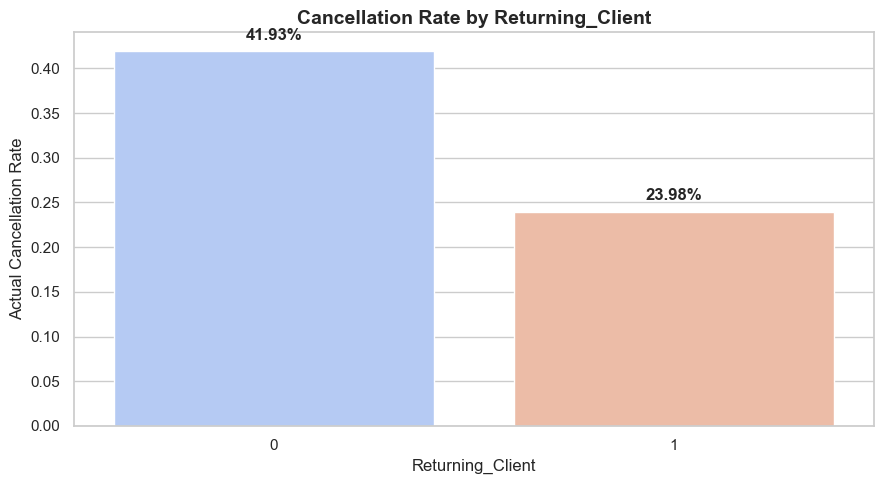

In [242]:
df_temp = df_train.copy()  # Create a temporary copy for feature analysis

# 3. חישוב קורלציית פירסון עם משתנה המטרה
correlation = df_temp['Returning_Client'].corr(df_temp['Dropped_Course'])
print(f"Pearson Correlation between 'Returning_Client' and 'Dropped_Course': {correlation:.4f}\n")

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# אם הפיצ'ר הוא נומרי רציף - נצייר גרף צפיפות (KDE)
if df_temp['Returning_Client'].nunique() > 10:
    ax = sns.kdeplot(data=df_temp, x='Returning_Client', hue='Dropped_Course', fill=True, common_norm=False, palette='bwr', alpha=0.5)
    plt.title(f'Distribution of Returning_Client by Course Outcome', fontsize=14, fontweight='bold')
    plt.xlabel('Returning_Client')
else:
    # אם הפיצ'ר הוא קטגוריאלי/בדיד - נצייר את אחוז הביטולים לכל ערך
    summary = df_temp.groupby('Returning_Client')['Dropped_Course'].mean().reset_index()
    ax = sns.barplot(data=summary, x='Returning_Client', y='Dropped_Course', palette='coolwarm')
    for p in ax.patches:
        ax.annotate(f"{p.get_height()*100:.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', weight='bold')
    plt.title(f'Cancellation Rate by Returning_Client', fontsize=14, fontweight='bold')
    plt.ylabel('Actual Cancellation Rate')

plt.tight_layout()
plt.show()

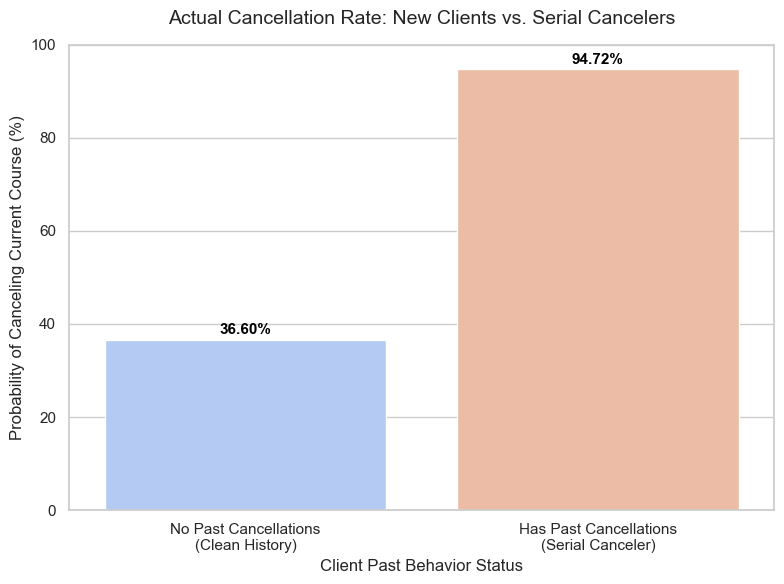

In [243]:
df_copy = df_train.copy()

df_copy['Had_Past_Cancellations'] = (df_copy['Prev_Course_Dropouts'] > 0).astype(int)

# 2. Calculate the actual cancellation rate (mean of Dropped_Course * 100)
cancellation_rates = df_copy.groupby('Had_Past_Cancellations')['Dropped_Course'].mean() * 100

# 3. Plotting the results
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=cancellation_rates.index, y=cancellation_rates.values, palette='coolwarm')

# Visual styling
plt.title('Actual Cancellation Rate: New Clients vs. Serial Cancelers', fontsize=14, pad=15)
plt.xlabel('Client Past Behavior Status', fontsize=12)
plt.ylabel('Probability of Canceling Current Course (%)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Past Cancellations\n(Clean History)', 'Has Past Cancellations\n(Serial Canceler)'])
plt.ylim(0, 100)

# Adding percentage labels on top of the bars for ultimate clarity
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 2), 
                ha='center', va='center', fontsize=11, color='black', weight='bold')

plt.tight_layout()
plt.show()

#### 1.4 The "Serial Canceler" Effect

* **The Discovery:** While our initial correlation matrix showed a moderate positive Pearson correlation (+0.20) between `Prev_Course_Dropouts` and `Dropped_Course`, a percentage-based segmentation reveals a staggering behavioral anchor. 
* **The Numbers:** * Clients with a **clean history** (no past dropouts) have a baseline cancellation rate of **36.60%**.
  * Clients with **at least one past dropout** exhibit a near-certain cancellation rate of **94.72%**.

#### Business & Modeling Implications:
1. **Predictive Power:** This single binary feature (`Is_Serial_Canceler`) acts as an incredibly strong separator. Our tree-based models (XGBoost) will heavily rely on this branch to isolate high-risk corporate accounts.
2. **Operational Risk Management:** For Nova Academy's operations team, any incoming reservation from an account with a history of cancellations should trigger immediate mitigation protocols (e.g., non-refundable deposits or holding off on cloud-lab environment provisioning) to eliminate wasted upfront costs.

### 1.5 Data Cleaning: Converting System Anomalies to Missing Values (NaN)
Before applying imputation techniques, we must isolate the business-logic violations and system placeholders discovered during the EDA phase. Instead of dropping these rows—which would prevent our pipeline from processing similar anomalies if they appear in the test set—we systematically replace them with `np.nan`.

**Anomalies Handled:**
* `Students_Count` == 9999 (System placeholder)
* `Practical_Hours` == 10000 (Data entry error)
* `Practical_Hours` < 0 (Logical violation)
* `Practical_Hours` ==0 && `Practical Hours`==0  (a course with zero hours cant exist)

In [244]:
# Create a copy of the dataframe to keep the raw data intact
df_cleaned=df_train.copy()

# 1. Handle Students_Count placeholder (9999)
df_cleaned['Students_Count'] = df_cleaned['Students_Count'].replace(9999, np.nan)

# 2. Handle Practical_Hours extreme outlier (10000)
df_cleaned['Practical_Hours'] = df_cleaned['Practical_Hours'].replace(10000, np.nan)

# 3. Handle Practical_Hours negative values (< 0)
df_cleaned.loc[df_cleaned['Practical_Hours'] < 0, 'Practical_Hours'] = np.nan

#4. Handle Daily_Tuition_Cost extreme outlier (> 1000)
df_cleaned.loc[df_cleaned['Daily_Tuition_Cost'] > 1000, 'Daily_Tuition_Cost'] = np.nan

#5 Locate the ghost courses and set their hours to NaN so the median imputer can fix them
ghost_courses_mask = (df_cleaned['Practical_Hours'] == 0) & (df_cleaned['Theory_Hours'] == 0)
df_cleaned.loc[ghost_courses_mask, ['Practical_Hours', 'Theory_Hours']] = np.nan

# Verification: Updated to include all cleaned continuous columns
# List of non-categorical (numerical) features that act as discrete counters or metrics
discrete_numerical_cols = [
    'Professionals_Count', 'Students_Count', 'Observers_Count', 
    'Prev_Course_Dropouts', 'Prev_Course_Attended', 'Pre_Course_Supports_Tickets', 
    'Physical_Course_Kits', 'Waiting_List_Days', 'Registration_Changes','Practical_Hours','Theory_Hours', 'Daily_Tuition_Cost'
]

print("=== Unique Values in Discrete Numerical Columns (Sorted) ===")
for col in discrete_numerical_cols:
    # Get unique values, drop NaN for clean view, and sort them
    unique_vals = sorted(df_cleaned[col].dropna().unique())
    print(f"\nUnique keys for {col}:")
    print(unique_vals)

=== Unique Values in Discrete Numerical Columns (Sorted) ===

Unique keys for Professionals_Count:
[0, 1, 2, 3, 4]

Unique keys for Students_Count:
[0.0, 1.0, 2.0, 3.0]

Unique keys for Observers_Count:
[0, 1, 2, 9, 10]

Unique keys for Prev_Course_Dropouts:
[0, 1, 2, 3, 4, 5, 6, 11, 13, 21]

Unique keys for Prev_Course_Attended:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]

Unique keys for Pre_Course_Supports_Tickets:
[0, 1, 2, 3, 4, 5]

Unique keys for Physical_Course_Kits:
[0.0, 1.0, 2.0, 3.0]

Unique keys for Waiting_List_Days:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 27, 28, 30, 31, 32, 33, 34, 35, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 53, 55, 56, 57, 58, 59, 60, 61, 62, 63, 65, 68, 69, 70, 71, 72, 74, 75, 76, 77, 79, 80, 81, 8

### Data Preparation / Preprocessing
* outlier remoival 
* filling missing values
* dimesionality reduction
* Data transformation / normalization

### 1.7 Categorical Data Standardization & Punctuation Removal
To completely eliminate "Dirty Categorical Data," we applied a strict Regular Expression (Regex) pipeline across all text-based variables. This pipeline forces lowercase uniformity, strips trailing whitespaces, and systematically strips out unwanted punctuation marks (e.g., '!', '?', or special characters) that could cause formatting fragmentation. Finally, any corrupt or empty strings are mapped directly to a unified `'unknown'` token.

In [245]:
import re

# List of all categorical columns to clean thoroughly
all_categorical_cols = [
    'Origin_Country', 'Catering_Package', 'Welcome_Gift_Type', 
    'Requested_Lab_Config', 'Assigned_Lab_Config', 'Enrollment_Type', 
    'Lanyard_Color', 'Client_Category', 'Submission_Source', 'Payment_Terms'
]

for col in all_categorical_cols:
    if col in df_cleaned.columns:
    
        df_cleaned[col] = df_cleaned[col].fillna('unknown')
        
        df_cleaned[col] = df_cleaned[col].astype(str).str.lower().str.strip()
        
        df_cleaned[col] = df_cleaned[col].str.replace(r'[^\w\s]', '', regex=True).str.strip()
        
        placeholders = ['', ' ', '?', 'nan', 'none', 'null', 'missing']
        df_cleaned[col] = df_cleaned[col].replace(placeholders, 'unknown')

# Verify the final clean state
# List of all categorical (text-based) columns
all_categorical_cols = [
    'Origin_Country', 'Catering_Package', 'Welcome_Gift_Type', 
    'Requested_Lab_Config', 'Assigned_Lab_Config', 'Enrollment_Type', 
    'Lanyard_Color', 'Client_Category', 'Submission_Source', 'Payment_Terms'
]

print("=== Unique Values in Categorical Columns ===")
for col in all_categorical_cols:
    unique_vals = df_cleaned[col].unique()
    print(f"\nClean keys for '{col}' ({len(unique_vals)} total):")
    print(list(unique_vals))

=== Unique Values in Categorical Columns ===

Clean keys for 'Origin_Country' (155 total):
['prt', 'unknown', 'ita', 'bra', 'esp', 'nld', 'gbr', 'deu', 'fra', 'rou', 'swe', 'aut', 'bel', 'ago', 'che', 'nor', 'rus', 'isr', 'pol', 'irl', 'bgr', 'usa', 'chn', 'dza', 'mar', 'aus', 'tun', 'moz', 'mex', 'dnk', 'grc', 'col', 'lux', 'cn', 'lva', 'fin', 'hrv', 'stp', 'ukr', 'ven', 'irn', 'twn', 'kor', 'tur', 'blr', 'jpn', 'cze', 'kaz', 'hun', 'cpv', 'aze', 'lbn', 'cri', 'arg', 'nzl', 'ind', 'idn', 'ltu', 'svk', 'srb', 'svn', 'cmr', 'egy', 'lie', 'sau', 'mys', 'mmr', 'chl', 'irq', 'sgp', 'dom', 'pan', 'sen', 'per', 'jor', 'zaf', 'lka', 'kna', 'tha', 'geo', 'kwt', 'tmp', 'alb', 'eth', 'mus', 'ecu', 'phl', 'are', 'omn', 'bfa', 'and', 'arm', 'ken', 'hnd', 'mco', 'nga', 'gnb', 'lby', 'rwa', 'est', 'pak', 'tza', 'gib', 'zmb', 'qat', 'khm', 'hkg', 'bgd', 'mli', 'isl', 'uzb', 'bih', 'bhr', 'ury', 'nam', 'bol', 'imn', 'cyp', 'tjk', 'mdv', 'mlt', 'nic', 'jam', 'syc', 'pry', 'brb', 'abw', 'ggy', 'aia', 's

#### 1.8 Categorical Data Imputation Strategy
For text-based, categorical features (`Origin_Country`, `Catering_Package`, `Welcome_Gift_Type`, `Requested_Lab_Config`, `Assigned_Lab_Config`, `Enrollment_Type`, `Lanyard_Color`, `Client_Category`, `Submission_Source`, `Payment_Terms`), we avoided using the standard statistical mode (most frequent value). Instead, we implemented a **string-standardization and explicit placeholder strategy**:

1. **Text Normalization & Cleaning:** All categorical fields were converted to lowercase, stripped of leading/trailing whitespaces, and cleared of special characters/punctuation using Regex to ensure structural uniformity.
2. **Explicit 'unknown' Assignment:** Standard statistical missing values (`NaN`), empty strings, and ambiguous placeholders (such as `'nan'`, `'none'`, `'null'`, `'?'`) were unified and replaced with a single explicit string: `'unknown'` and will be handeled later.


Checking for NaN Vals in each feature

In [246]:
df_analysis = df_cleaned.copy()

numerical_cols = df_analysis.select_dtypes(include=['number']).columns
categorical_cols = df_analysis.select_dtypes(include=['object', 'category']).columns

numeric_nans = df_analysis[numerical_cols].isna().sum()
if 'Agent_ID' in numeric_nans.index:
    numeric_nans = numeric_nans.drop('Agent_ID')

numeric_summary = pd.DataFrame({'NaN Counts': numeric_nans})
numeric_summary = numeric_summary[numeric_summary['NaN Counts'] > 0]

cat_unknown = pd.Series(0, index=categorical_cols)
for col in categorical_cols:
    cat_unknown[col] = (df_analysis[col] == 'unknown').sum()

categorical_summary = pd.DataFrame({'Unknown Counts': cat_unknown})
categorical_summary = categorical_summary[categorical_summary['Unknown Counts'] > 0]

print("==================================================")
print("    NUMERICAL FEATURES MISSING DATA (NaNs)      ")
print("==================================================")
if not numeric_summary.empty:
    print(numeric_summary.sort_values(by='NaN Counts', ascending=False))
else:
    print("✓ Clean! Zero NaNs found in target numerical features.")

print("\n")

print("==================================================")
print("    CATEGORICAL FEATURES (Unknown Counts)      ")
print("==================================================")
if not categorical_summary.empty:
    print(categorical_summary.sort_values(by='Unknown Counts', ascending=False))
else:
    print("✓ Clean! Zero unknown values found in categorical features.")
print("==================================================")

    NUMERICAL FEATURES MISSING DATA (NaNs)      
                          NaN Counts
Company_ID                     60344
Registration_Days_Before        2666
Physical_Course_Kits            1040
Practical_Hours                  396
Theory_Hours                     309
Daily_Tuition_Cost                80
Students_Count                    59


    CATEGORICAL FEATURES (Unknown Counts)      
                      Unknown Counts
Requested_Lab_Config            1736
Submission_Source               1014
Payment_Terms                   1006
Enrollment_Type                  719
Origin_Country                   557
Catering_Package                 407
Client_Category                    2


#### 1.9 Differentiated Numerical Imputation Strategy
Instead of blindly applying a global median to all numerical fields, we applied a business-driven split strategy:
1. **Median Imputer:** Applied to skewed, continuous variables (`Registration_Days_Before`, `Daily_Tuition_Cost`, `Physical_Course_Kits`) to remain robust against valid long-tail distributions.
2. **Constant Zero Imputer:** Applied specifically to `Students_Count`. Rather than assuming a missing value represents a generic median class size, business logic dictates that an omission likely implies zero students were enrolled for that specific iteration (e.g., a technical-only or observer-only setup). This preserves structural integrity and allows clean integer casting without synthetic inflation.

In [247]:
median_numerical_cols = ['Registration_Days_Before', 'Physical_Course_Kits', 'Daily_Tuition_Cost', 'Practical_Hours', 'Theory_Hours']

median_imputer = SimpleImputer(strategy='median')
zero_imputer = SimpleImputer(strategy='constant', fill_value=0) # מילוי קבוע ב-0 לסטודנטים

df_cleaned[median_numerical_cols] = median_imputer.fit_transform(df_cleaned[median_numerical_cols])
df_cleaned[['Students_Count']] = zero_imputer.fit_transform(df_cleaned[['Students_Count']])

df_cleaned['Students_Count'] = df_cleaned['Students_Count'].astype(int)
df_cleaned['Physical_Course_Kits'] = df_cleaned['Physical_Course_Kits'].astype(int)

print(f"✓ Pipeline complete with Business Logic Zero-Imputation!")
print(f"✓ Final df_cleaned shape: {df_cleaned.shape}")
print(f"✓ Total remaining NaNs : {df_cleaned.isnull().sum().sum()}")

✓ Pipeline complete with Business Logic Zero-Imputation!
✓ Final df_cleaned shape: (63464, 29)
✓ Total remaining NaNs : 71517


## Categorial Features - fill unknown values strategy:

* 1.**Agent_ID** we decided to fill the `Agent_ID` missing values with -1 Instead of corrupting the data by filling missing agent values with a median (e.g., attributing 11,173 courses to a random salesperson), we filled these missing entries with `-1`. In our domain logic, a missing agent ID strongly signifies an independent registration. Assigning `-1` isolates these entries into a unique, highly informative category.
* 2.**Origin_Country** - Probabilistic Imputation (to maintain proportion in the dataset)
* 3.**Catering_Package** - standart (if didnt chose assignes standart)
* 4.**Requested_Lab_Config** - "No Request"
* 5.**Client_Category** - remains "unknown"
* 6. **Submmision_Source** - "Other Source"
* 7. **Payment_Terms** -  Probabilistic Imputation (to maintain proportion in the dataset)
* 8. **Enrollment_Type** - remains "unknown"

In [248]:

df_cleaned['Agent_ID'] = df_cleaned['Agent_ID'].fillna(-1)
df_cleaned['Submission_Source'] = df_cleaned['Submission_Source'].replace('unknown', 'Other Source')
df_cleaned['Requested_Lab_Config'] = df_cleaned['Requested_Lab_Config'].replace('unknown', 'No Request')
df_cleaned['Catering_Package'] = df_cleaned['Catering_Package'].replace('unknown', 'standard coffee only')
df_cleaned['Payment_Terms'] = df_cleaned['Payment_Terms'].replace('unknown', np.nan)

payment_probs = df_cleaned['Payment_Terms'].value_counts(normalize=True)
payment_isnull = df_cleaned['Payment_Terms'].isnull()
num_payment_nulls = payment_isnull.sum()

if num_payment_nulls > 0:
    random_payments = np.random.choice(
        a=payment_probs.index, 
        size=num_payment_nulls, 
        p=payment_probs.values
    )
    df_cleaned.loc[payment_isnull, 'Payment_Terms'] = random_payments


df_cleaned['Origin_Country'] = df_cleaned['Origin_Country'].replace('unknown', np.nan)

country_probs = df_cleaned['Origin_Country'].value_counts(normalize=True)
country_isnull = df_cleaned['Origin_Country'].isnull()
num_country_nulls = country_isnull.sum()

if num_country_nulls > 0:
    random_countries = np.random.choice(
        a=country_probs.index, 
        size=num_country_nulls, 
        p=country_probs.values
    )
    df_cleaned.loc[country_isnull, 'Origin_Country'] = random_countries

------------------------------------------------------------------------------------------

## Part B: Feature Engineering
* Dimensionality reduction 
* Ctegorial Data transformation  
* Feature engineering
* Numerical Data normalization 

***🗑️ Dimensionality reduction - Feature Dropping:*** 
* `Company_ID` - The Company_ID feature was dropped because it contains ~95% missing values (60,344 NaNs), meaning any imputation would introduce severe statistical noise into our model.

* `Practical_hours` - due to zero correlation with the target (correlation matrix at part A)

* `Client_ID` - a random client ID wont give us useful information

* `Lanyard_Color` - as shown below for Lanyard_Color feature the dropout rate (1) remains virtually identical (around 41.5%) across all colors, proving it has zero predictive power or correlation with the target variable.



In [249]:
print(pd.crosstab(df_cleaned['Lanyard_Color'], df_cleaned['Dropped_Course'], normalize='index') * 100)

Dropped_Course          0          1
Lanyard_Color                       
black           58.541681  41.458319
blue            58.641236  41.358764
green           58.314937  41.685063
orange          58.344790  41.655210
red             58.409786  41.590214


In [250]:
df_cleaned = df_cleaned.drop(columns=['Company_ID'], errors='ignore')
df_cleaned = df_cleaned.drop(columns=['Practical_Hours'], errors='ignore')
df_cleaned = df_cleaned.drop(columns=['Client_ID'], errors='ignore')
df_cleaned = df_cleaned.drop(columns=['Lanyard_Color'], errors='ignore')

print(f"✓ Columns dropped successfully! Remaining columns count: {len(df_cleaned.columns)}")

✓ Columns dropped successfully! Remaining columns count: 25


##  Categorial Data Transformation 

#### Data transformation for `Course_Start_Date` (new features)
* changing the string feature `Course_Start_Date` to binary features to gather useable data 


In [251]:
df_cleaned['Course_Start_Date'] = pd.to_datetime(df_cleaned['Course_Start_Date'])
df_cleaned['Course_Start_Month'] = df_cleaned['Course_Start_Date'].dt.month
df_cleaned['Course_Start_Quarter'] = df_cleaned['Course_Start_Date'].dt.quarter
df_cleaned['Course_Start_DayOfWeek'] = df_cleaned['Course_Start_Date'].dt.dayofweek
df_cleaned = df_cleaned.drop(columns=['Course_Start_Date'])

print("✓ Date features successfully engineered into numerical cyclical features!")
print(df_cleaned[['Course_Start_Month', 'Course_Start_Quarter', 'Course_Start_DayOfWeek']].head())

✓ Date features successfully engineered into numerical cyclical features!
   Course_Start_Month  Course_Start_Quarter  Course_Start_DayOfWeek
0                   7                     3                       2
1                   7                     3                       2
2                   7                     3                       2
3                   7                     3                       2
4                   7                     3                       2


### OneHotEncoding / Dummy variables ###

Performed OneHotEncoding to the following features: 'Catering_Package', 'Welcome_Gift_Type', 'Enrollment_Type', 'Client_Category', 'Submission_Source', 'Payment_Terms'
the other features will be handled seperatly.

In [252]:

from sklearn.preprocessing import OneHotEncoder

cleaned_categorial_cols = ['Catering_Package', 'Welcome_Gift_Type', 'Enrollment_Type', 'Client_Category', 'Submission_Source', 'Payment_Terms','Course_Start_Month','Course_Start_Quarter','Course_Start_DayOfWeek']  
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df_cleaned[cleaned_categorial_cols])
encoded_df = pd.DataFrame(
    encoded_array, 
    columns=encoder.get_feature_names_out(cleaned_categorial_cols),
    index=df_cleaned.index
)
df_encoded = df_cleaned.drop(columns=cleaned_categorial_cols).join(encoded_df)
print(df_encoded.columns.tolist())


['Professionals_Count', 'Students_Count', 'Observers_Count', 'Theory_Hours', 'Registration_Days_Before', 'Origin_Country', 'Requested_Lab_Config', 'Assigned_Lab_Config', 'Prev_Course_Dropouts', 'Prev_Course_Attended', 'Pre_Course_Supports_Tickets', 'Physical_Course_Kits', 'Waiting_List_Days', 'Registration_Changes', 'Returning_Client', 'Agent_ID', 'Daily_Tuition_Cost', 'Dropped_Course', 'Catering_Package_lunch included', 'Catering_Package_no food plan', 'Catering_Package_standard coffee only', 'Welcome_Gift_Type_portable charger', 'Welcome_Gift_Type_usb drive', 'Welcome_Gift_Type_water bottle', 'Enrollment_Type_contractual agreement', 'Enrollment_Type_general admission', 'Enrollment_Type_organizational arrangement', 'Enrollment_Type_unknown', 'Client_Category_defense  govtech', 'Client_Category_fintech  banking', 'Client_Category_industrial tech  iot', 'Client_Category_nonprofit  edutech', 'Client_Category_saas  software houses', 'Client_Category_traditional it  telecomm', 'Client_Cate

### Origin_Country investigation and startegy

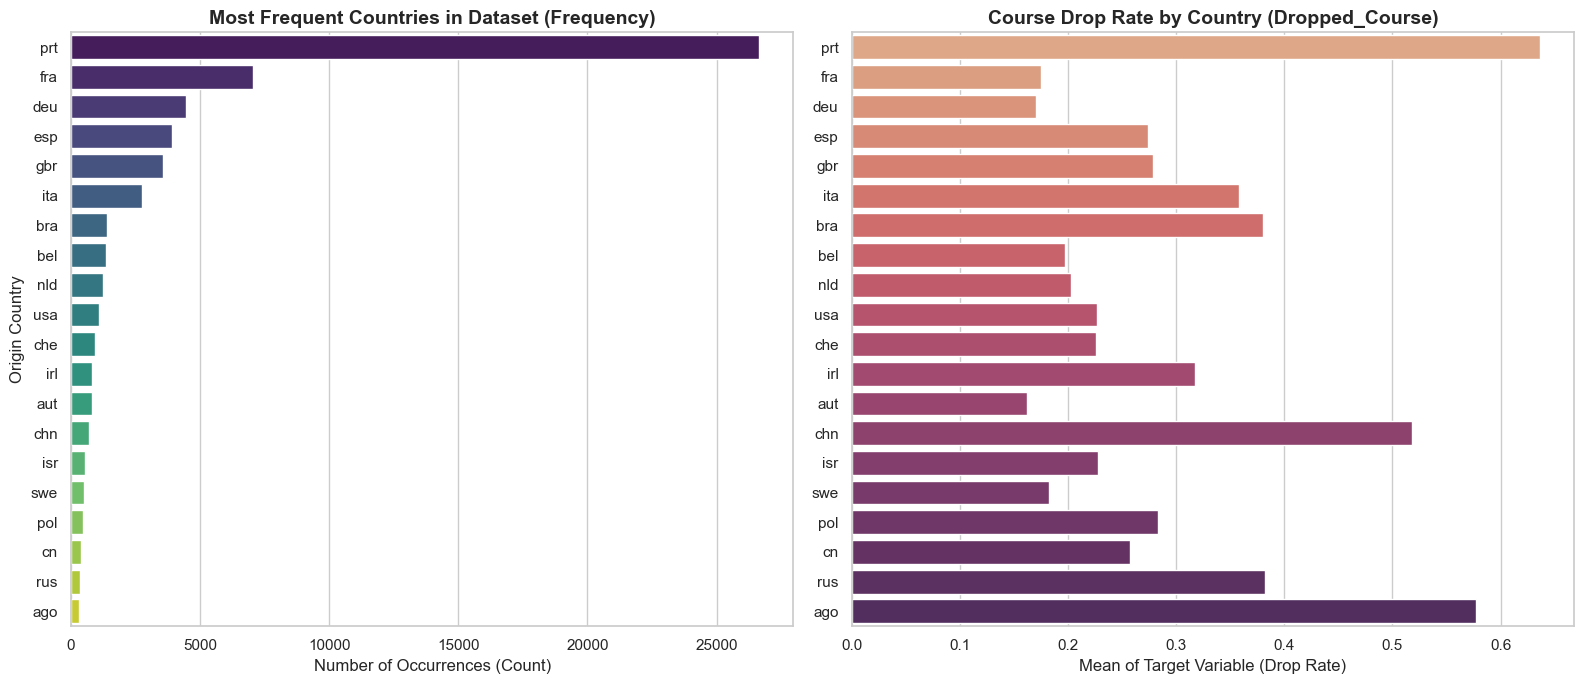

In [253]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# Get the top 20 most frequent countries to keep the visualization clean
top_countries = df_encoded['Origin_Country'].value_counts().head(20).index
df_filtered = df_encoded[df_encoded['Origin_Country'].isin(top_countries)]
# --- Plot 1: Country Frequencies (Frequency Encoding Analysis) ---

sns.countplot(

    data=df_filtered,
    y='Origin_Country',
    order=top_countries,
    ax=axes[0],
    palette='viridis'
)

axes[0].set_title('Most Frequent Countries in Dataset (Frequency)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Occurrences (Count)')
axes[0].set_ylabel('Origin Country')
 
country_target_means = df_filtered.groupby('Origin_Country')['Dropped_Course'].mean().loc[top_countries]
sns.barplot(
    x=country_target_means.values,
    y=country_target_means.index,
    ax=axes[1],
    palette='flare'
)

axes[1].set_title('Course Drop Rate by Country (Dropped_Course)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mean of Target Variable (Drop Rate)')
axes[1].set_ylabel('') 

plt.tight_layout()

plt.show()
 

### 1. Key Findings
* **Frequency:** The data features a severe "long-tail" distribution. A single country (`prt`) dominates with >25k rows, while most other countries have extremely low representation.
* **Target Variance:** The target variable (`Dropped_Course`) varies drastically by country—ranging from nearly **65%** (high risk for `prt`) to under **20%** (low risk for `aut`, `swe`).
 
### 2. Strategy: Target Encoding with Smoothing
We selected **Target Encoding** because country of origin is a powerful predictor of drop rates. However, to eliminate the risk of **overfitting on minority countries** (small sample sizes), we implemented **Empirical Bayesian Smoothing**.
 
#### How Smoothing Works:
* **High-volume countries (e.g., `prt`):** The encoder relies heavily on the country's actual drop rate.
* **Low-volume countries:** The encoder distrusts the small sample size and pulls ("smoothes") the value toward the **global baseline average** of the entire dataset.

In [254]:
global_mean = df_encoded['Dropped_Course'].mean()
stats = df_encoded.groupby('Origin_Country')['Dropped_Course'].agg(['mean', 'count'])
smoothing_factor = 50.0
stats['weight'] = stats['count'] / (stats['count'] + smoothing_factor)
stats['encoded_value'] = (stats['weight'] * stats['mean']) + ((1 - stats['weight']) * global_mean)
df_encoded['Origin_Country'] = df_encoded['Origin_Country'].map(stats['encoded_value'])
 

 ### New Feature Brainstorming (investigation)

####  Registration Time Feature EDA (for registration days before)

--- טבלת סיכויי ביטול והצלחה לפי חלונות זמן ---
Registration_Window  Total_Registrations  Cancellation_Rate  Success_Rate
       Same Day (0)                 2610           0.082375      0.917625
           1-3 Days                 3416           0.123536      0.876464
           4-7 Days                 3041           0.153897      0.846103
          8-14 Days                 3737           0.251271      0.748729
         15-30 Days                 6335           0.339384      0.660616
         1-2 Months                 9953           0.387923      0.612077
         2-3 Months                10045           0.417621      0.582379
          3+ Months                24327           0.577506      0.422494

[V] הגרף registration_time_eda.png נשמר בהצלחה!

--- נקודות החיתוך (Thresholds) האופטימליות שמצא האלגוריתם ---
|--- Registration_Days_Before <= 257.50
|   |--- Registration_Days_Before <= 17.50
|   |   |--- class: 0
|   |--- Registration_Days_Before >  17.50
|   |   |--- class: 0
|---

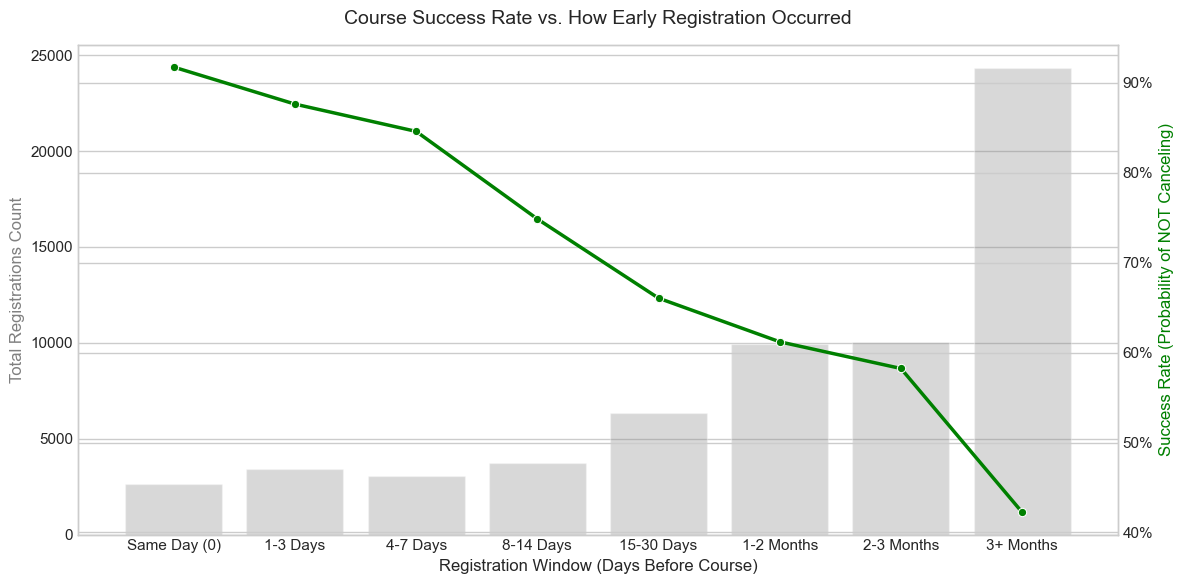

In [255]:
from sklearn.tree import DecisionTreeClassifier, export_text

bins = [-1, 0, 3, 7, 14, 30, 60, 90, np.inf]
labels = ['Same Day (0)', '1-3 Days', '4-7 Days', '8-14 Days', '15-30 Days', '1-2 Months', '2-3 Months', '3+ Months']

df_encoded['Registration_Window'] = pd.cut(df_encoded['Registration_Days_Before'], bins=bins, labels=labels)

eda_summary = df_encoded.groupby('Registration_Window', observed=False).agg(
    Total_Registrations=('Dropped_Course', 'count'),
    Cancellation_Rate=('Dropped_Course', 'mean')
).reset_index()

eda_summary['Success_Rate'] = 1 - eda_summary['Cancellation_Rate']

print("--- טבלת סיכויי ביטול והצלחה לפי חלונות זמן ---")
print(eda_summary.to_string(index=False))
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=eda_summary, x='Registration_Window', y='Total_Registrations', alpha=0.3, color='gray', ax=ax1)
ax1.set_ylabel('Total Registrations Count', color='gray')
ax1.set_xlabel('Registration Window (Days Before Course)')

ax2 = ax1.twinx()
sns.lineplot(data=eda_summary, x='Registration_Window', y='Success_Rate', marker='o', color='green', linewidth=2.5, ax=ax2)
ax2.set_ylabel('Success Rate (Probability of NOT Canceling)', color='green')
ax2.yaxis.set_major_formatter(lambda x, pos: f'{x*100:.0f}%')

plt.title('Course Success Rate vs. How Early Registration Occurred', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('registration_time_eda.png')
print("\n[V] הגרף registration_time_eda.png נשמר בהצלחה!")

df_tree = df_cleaned[['Registration_Days_Before', 'Dropped_Course']].dropna()

X = df_tree[['Registration_Days_Before']]
y = df_tree['Dropped_Course']

tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X, y)

tree_rules = export_text(tree, feature_names=['Registration_Days_Before'])
print("\n--- נקודות החיתוך (Thresholds) האופטימליות שמצא האלגוריתם ---")
print(tree_rules)

## EDA Insights & Next Steps: Registration Window

### Key Insights
* **Last-Minute Sign-ups are Stable:** Clients registering on the **Same Day (0)** have a **91.76% success rate** (only 8.2% cancel).
* **Early Birds are Risky:** The earlier a client registers, the more likely they are to drop out. Registering **3+ Months** ahead drops the success rate to **42.25%** (57.7% cancel).
* **Takeaway:** Early registrations are highly volatile, while spontaneous registrations show strong intent.

### Next Steps: Feature Encoding
To safely feed these temporal insights into our models without causing linear distortions, we are converting the following categorical features into binary dummy variables (0 or 1) via **One-Hot Encoding**:
* `Registration_Window`
* `Course_Start_Month` / `Quarter` / `DayOfWeek`

In [256]:
bins = [-1, 0, 3, 7, 14, 30, 60, 90, float('inf')]
labels = ['Same Day (0)', '1-3 Days', '4-7 Days', '8-14 Days', '15-30 Days', '1-2 Months', '2-3 Months', '3+ Months']
df_encoded['Registration_Window'] = pd.cut(df_encoded['Registration_Days_Before'], bins=bins, labels=labels)

df_encoded['Registration_Window'] = df_encoded['Registration_Window'].astype(str)

# 3. יצירת משתני הדאמי (One-Hot Encoding)
df_encoded = pd.get_dummies(df_encoded, columns=['Registration_Window'], drop_first=True)
print("[V] Success! 'Registration_Window' created and encoded into dummy variables.")

[V] Success! 'Registration_Window' created and encoded into dummy variables.


###  EDA for The Binary Feature : `Has_Registration_Changes`

Pearson Correlation Coefficient: -0.1950

--- Cancellation Rates by Registration Changes ---
          Status  Total_Count  Cancellation_Rate
  No Changes (0)        55478           0.450845
Had Changes (1+)         7986           0.161157




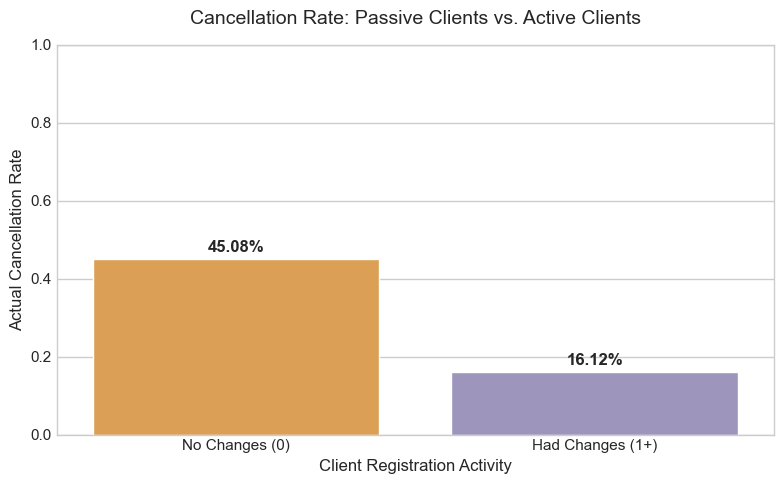

In [257]:
# temp data frame for EDA to analyze the effect of the binary feature on course dropouts
df_temp = df_encoded.copy()

# # 1. Create the binary feature on the temporary dataframe
df_temp['Has_Registration_Changes'] = (df_temp['Registration_Changes'] > 0).astype(int)

# # 2. Calculate Pearson correlation coefficient
binary_corr = df_temp['Has_Registration_Changes'].corr(df_temp['Dropped_Course'])
print(f"Pearson Correlation Coefficient: {binary_corr:.4f}\n")

# # 3. Calculate actual cancellation rates
summary = df_temp.groupby('Has_Registration_Changes').agg(
    Total_Count=('Dropped_Course', 'count'),
    Cancellation_Rate=('Dropped_Course', 'mean')
).reset_index()

summary['Status'] = summary['Has_Registration_Changes'].map({0: 'No Changes (0)', 1: 'Had Changes (1+)'})

print("--- Cancellation Rates by Registration Changes ---")
print(summary[['Status', 'Total_Count', 'Cancellation_Rate']].to_string(index=False))
print("\n")

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=summary, x='Status', y='Cancellation_Rate', palette=['#f1a340', '#998ec3'])

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                ha='center', va='center', 
                xytext=(0, 5),             
                textcoords='offset points', weight='bold')

plt.title('Cancellation Rate: Passive Clients vs. Active Clients', fontsize=14, pad=15)
plt.ylabel('Actual Cancellation Rate')
plt.xlabel('Client Registration Activity')
plt.ylim(0, 1.0)
plt.tight_layout()


plt.savefig('has_changes_binary_eda.png')
plt.show()

### Creating And Checking The Binary Feature : `Is_Digital_Registration`

Pearson Correlation Coefficient: -0.0744

--- Cancellation Rates by Registration Type ---
                  Registration_Type  Total_Count  Cancellation_Rate
        Via Agent (Agent_ID exists)        52291           0.431336
Digital / Self-Reg (Agent_ID == -1)        11173           0.335094




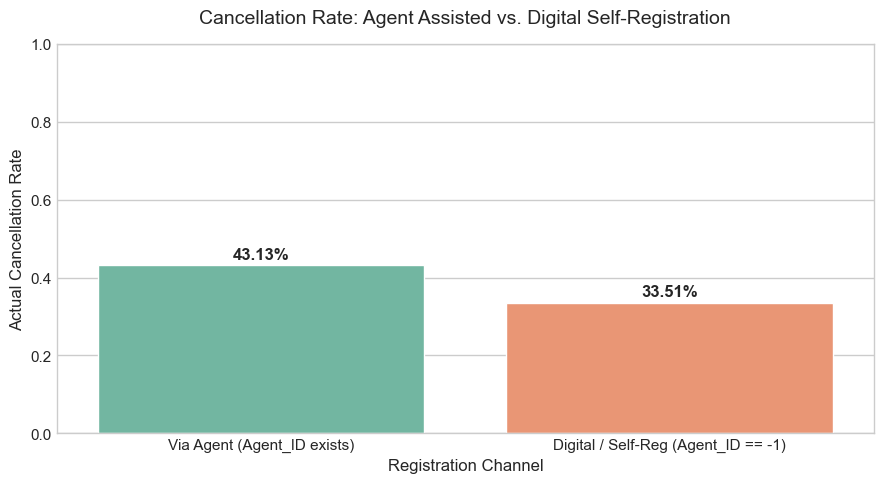

In [258]:

# temp data frame for EDA to analyze the effect of the binary feature on course dropouts
df_temp = df_encoded.copy()

# # 1. Create the binary feature on the temporary dataframe
df_temp['Is_Digital_Registration'] = (df_temp['Agent_ID'] == -1).astype(int)

# # 2. Calculate Pearson correlation coefficient
digital_corr = df_temp['Is_Digital_Registration'].corr(df_temp['Dropped_Course'])
print(f"Pearson Correlation Coefficient: {digital_corr:.4f}\n")

# # 3. Calculate actual cancellation rates
summary = df_temp.groupby('Is_Digital_Registration').agg(
    Total_Count=('Dropped_Course', 'count'),
    Cancellation_Rate=('Dropped_Course', 'mean')
).reset_index()

summary['Registration_Type'] = summary['Is_Digital_Registration'].map({
    0: 'Via Agent (Agent_ID exists)', 
    1: 'Digital / Self-Reg (Agent_ID == -1)'
})

print("--- Cancellation Rates by Registration Type ---")
print(summary[['Registration_Type', 'Total_Count', 'Cancellation_Rate']].to_string(index=False))
print("\n")

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=summary, x='Registration_Type', y='Cancellation_Rate', palette='Set2')

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                ha='center', va='center', 
                xytext=(0, 5),             # התיקון כאן
                textcoords='offset points', weight='bold')

plt.title('Cancellation Rate: Agent Assisted vs. Digital Self-Registration', fontsize=14, pad=15)
plt.ylabel('Actual Cancellation Rate')
plt.xlabel('Registration Channel')
plt.ylim(0, 1.0)
plt.tight_layout()

plt.savefig('digital_registration_eda.png')
plt.show()

#### Checking how many agents to consider either dummy variables or creating just a `Is_Digital_Registration` feature

In [259]:
unique_agents_count = df_encoded['Agent_ID'].nunique()
print(f"Number of unique agents (including -1): {unique_agents_count}")

print("\n--- Top 10 Agents by Volume ---")
print(df_encoded['Agent_ID'].value_counts().head(10))

real_agents = df_encoded[df_encoded['Agent_ID'] != -1]['Agent_ID']
print(f"\nNumber of actual human agents (excluding -1): {real_agents.nunique()}")

Number of unique agents (including -1): 204

--- Top 10 Agents by Volume ---
 184.0    22109
-1.0      11173
 218.0     6551
 104.0     2577
 264.0     2380
 219.0     1983
 224.0     1312
 205.0     1074
 320.0     1071
 158.0      892
Name: Agent_ID, dtype: int64

Number of actual human agents (excluding -1): 203


### EDA Insights: Agent-Assisted vs. Digital Self-Registration

Analyzing the engineered `Is_Digital_Registration` feature reveals a notable variance in course dropout behavior based on the initial registration channel:

* **Via Agent (43.13% Drop Rate):** Clients whose registration involved a sales or support agent exhibit a higher propensity to cancel or drop out. This could point to a gap where agent-driven sales might push for alignment that doesn't fully match long-term student commitment.
* **Digital / Self-Registration (33.51% Drop Rate):** Clients who completed their registration independently (where `Agent_ID` was missing and mapped to `-1`) show a significantly lower dropout rate, reflecting a higher baseline of self-motivation and intent.

* **The Issue:** Applying One-Hot Encoding would add over 200 dummy columns, creating a highly sparse matrix and increasing the risk of overfitting. Furthermore, the data distribution is heavily skewed, with a single agent (`184.0`) dominating the volume alongside independent sign-ups.
* **The Solution:** Instead of inflating the dataset, we distilled the core behavioral signal into a single binary feature: `Is_Digital_Registration`. This feature captures a clean **~10% gap in dropout rates**

**Conclusion:** To maximize the signal-to-noise ratio and prevent multicollinearity, we drop the raw `Agent_ID` column and retain only `Is_Digital_Registration`.

### Support Tickets Per Course - EDA

Continuous Feature Correlation: -0.3016

Binary Feature Correlation (Threshold > 1.00): -0.1655

--- Cancellation Rates by Support Ticket Ratio Level ---
                  Status  Total_Count  Cancellation_Rate
Low/Normal Tickets Ratio        56258           0.443564
      High Tickets Ratio         7206           0.186650




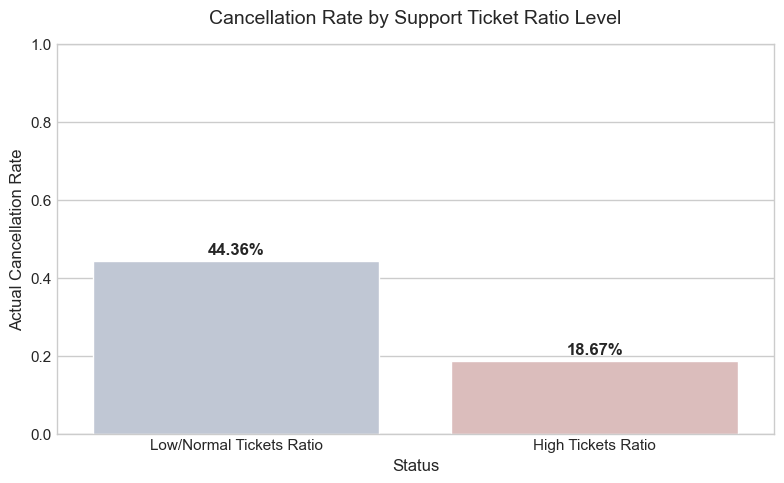

In [260]:
# 1. יצירת עותק זמני ומבודד לצורך הבדיקה
df_temp = df_encoded.copy()
total_past_courses = df_temp['Prev_Course_Dropouts'] + df_temp['Prev_Course_Attended']
df_temp['Support_Ticket_per_Course'] = df_temp['Pre_Course_Supports_Tickets'] / (total_past_courses + 1)
continuous_corr = df_temp['Support_Ticket_per_Course'].corr(df_temp['Dropped_Course'])
print(f"Continuous Feature Correlation: {continuous_corr:.4f}\n")
tickets_mesh = df_temp[df_temp['Pre_Course_Supports_Tickets'] > 0]['Support_Ticket_per_Course']
median_threshold = tickets_mesh.median() if len(tickets_mesh) > 0 else 0.5
df_temp['High_Support_Engagement'] = (df_temp['Support_Ticket_per_Course'] > median_threshold).astype(int)

binary_corr = df_temp['High_Support_Engagement'].corr(df_temp['Dropped_Course'])
print(f"Binary Feature Correlation (Threshold > {median_threshold:.2f}): {binary_corr:.4f}\n")

summary = df_temp.groupby('High_Support_Engagement').agg(
    Total_Count=('Dropped_Course', 'count'),
    Cancellation_Rate=('Dropped_Course', 'mean')
).reset_index()

summary['Status'] = summary['High_Support_Engagement'].map({0: 'Low/Normal Tickets Ratio', 1: 'High Tickets Ratio'})

print("--- Cancellation Rates by Support Ticket Ratio Level ---")
print(summary[['Status', 'Total_Count', 'Cancellation_Rate']].to_string(index=False))
print("\n")

# 6. Plot the comparison
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=summary, x='Status', y='Cancellation_Rate', palette='vlag')

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                ha='center', va='center', 
                xytext=(0, 5),             # התיקון הקריטי כאן
                textcoords='offset points', weight='bold')

plt.title('Cancellation Rate by Support Ticket Ratio Level', fontsize=14, pad=15)
plt.ylabel('Actual Cancellation Rate')
plt.ylim(0, 1.0)
plt.tight_layout()

plt.savefig('support_ticket_ratio_eda.png')
plt.show()

#### Dropout_Ratio Feature EDA 

c:\Users\Yahli\Downloads\Anaconda\envs\ml_hw1\lib\site-packages\seaborn\utils.py:482: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


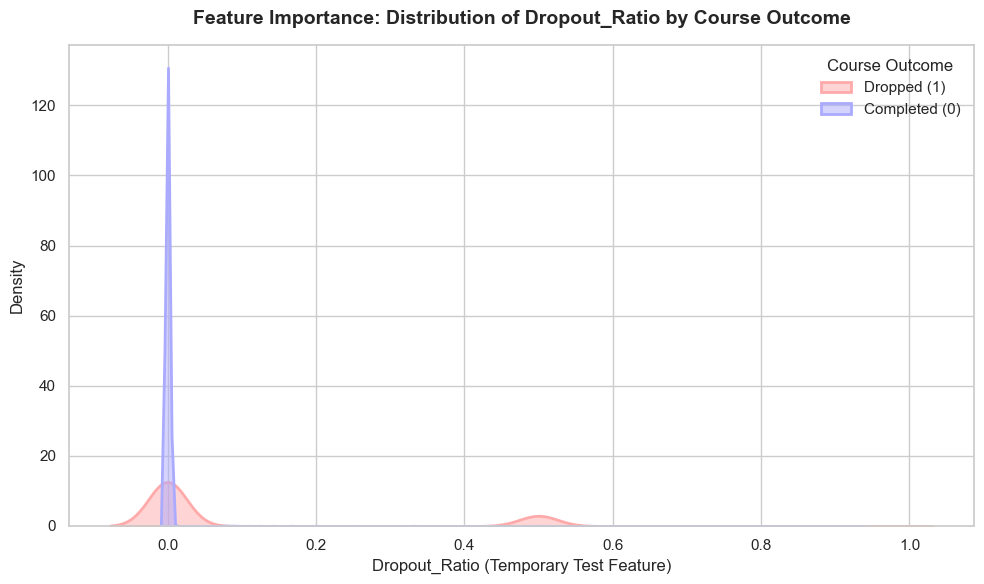

In [261]:
df_temp = df_encoded.copy()
#checking if the new feature is helpful before adding it to the main dataset. 

df_temp['Dropout_Ratio'] = df_temp['Prev_Course_Dropouts'] / (
    df_temp['Prev_Course_Dropouts'] + df_temp['Prev_Course_Attended'] + 1
)

# 3. הגדרת עיצוב וציור הגרף מהעותק הזמני
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.kdeplot(
    data=df_temp,  # <-- משתמשים בעותק הזמני
    x='Dropout_Ratio',
    hue='Dropped_Course',
    fill=True,
    common_norm=False,
    palette='bwr',
    alpha=0.5,
    linewidth=2
)

plt.title('Feature Importance: Distribution of Dropout_Ratio by Course Outcome', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Dropout_Ratio (Temporary Test Feature)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# עדכון ה-Legend בצורה נקייה
sns.move_legend(ax, "upper right", title='Course Outcome', labels=['Dropped (1)', 'Completed (0)'])

plt.tight_layout()
plt.show()

### EDA Insights: Dropout Ratio Distribution

Analysis of the newly engineered `Dropout_Ratio` feature demonstrates exceptionally high separability between classes, making it a powerful predictor for course outcomes:

* **The Zero-Dropout Anchor (~0.0 Ratio):** The density for students who completed the course (`Completed (0)`) spikes dramatically at exactly `0.0`. This indicates that a clean historical record (zero prior dropouts) is a massive indicator of successful course completion.
* **The High-Risk Peaks (>0.0 Ratio):** Conversely, as the ratio moves above zero—with a distinct secondary peak appearing around `0.5`—the distribution is occupied almost exclusively by students who dropped out (`Dropped (1)`). 

**Conclusion:** Students with a history of dropping out exhibit a starkly higher baseline risk of replicating that behavior. The clean, non-overlapping behavior of the distributions at key points confirms that `Dropout_Ratio` captures a vital behavioral signal for our machine learning model.

### Features Implementation
* *1 Registration Time Features:* `Reg_Within_7_Days` & `Reg_Over_90_Days_Before` - (following the Registration Time Feature EDA) 
* *2. Client Activity & Missingness Features:* `Has_Registration_Changes` (EDA for Has_Registration_Changes) `Is_Digital_Registration`(EDA Insights: Agent-Assisted vs. Digital Self-Registration) `Is_Serial_Canceler` ()
* *3. Historical Performance Ratios:* `Dropout_Ratio`(EDA Insights: Dropout Ratio Distribution) `Support_Ticket_per_Cours`(Support Tickets Per Course - EDA)

In [262]:
# 1. Registration Time Features
df_encoded['Reg_Within_7_Days'] = (df_encoded['Registration_Days_Before'] <= 7).astype(int)
df_encoded['Reg_Over_90_Days_Before'] = (df_encoded['Registration_Days_Before'] >= 90).astype(int)

# 2. Client Activity & Missingness Features
df_encoded['Has_Registration_Changes'] = (df_encoded['Registration_Changes'] > 0).astype(int)

df_encoded['Is_Digital_Registration'] = (df_encoded['Agent_ID'] == -1).astype(int)
#dropping the original Agent_ID column since we have already created a binary feature for it
df_encoded = df_encoded.drop(columns=['Agent_ID'], errors='ignore')

df_encoded['Is_Serial_Canceler'] = (df_encoded['Prev_Course_Dropouts'] > 0).astype(int)

# 3. Historical Performance Ratios (with smoothing to prevent division by zero)
df_encoded['Dropout_Ratio'] = df_encoded['Prev_Course_Dropouts'] / (df_encoded['Prev_Course_Dropouts'] + df_encoded['Prev_Course_Attended'] + 1)

total_past_courses = df_encoded['Prev_Course_Dropouts'] + df_encoded['Prev_Course_Attended']
df_encoded['Support_Ticket_per_Course'] = df_encoded['Pre_Course_Supports_Tickets'] / (total_past_courses + 1)

df_encoded.head(5)

,Professionals_Count,Students_Count,Observers_Count,Theory_Hours,Registration_Days_Before,Origin_Country,Requested_Lab_Config,Assigned_Lab_Config,Prev_Course_Dropouts,Prev_Course_Attended,...,Registration_Window_4-7 Days,Registration_Window_8-14 Days,Registration_Window_Same Day (0),Reg_Within_7_Days,Reg_Over_90_Days_Before,Has_Registration_Changes,Is_Digital_Registration,Is_Serial_Canceler,Dropout_Ratio,Support_Ticket_per_Course
0,2,0,0,2.0,257.0,0.635747,standard pc windows,standard pc windows,0,0,...,0,0,0,0,1,0,0,0,0.0,0.0
1,1,0,0,2.0,257.0,0.635747,standard pc windows,standard pc windows,0,0,...,0,0,0,0,1,1,0,0,0.0,0.0
2,1,0,0,2.0,257.0,0.635747,standard pc windows,standard pc windows,0,0,...,0,0,0,0,1,1,0,0,0.0,0.0
3,2,0,0,2.0,257.0,0.635747,standard pc windows,standard pc windows,0,0,...,0,0,0,0,1,0,0,0,0.0,0.0
4,1,0,0,2.0,257.0,0.635747,standard pc windows,standard pc windows,0,0,...,0,0,0,0,1,1,0,0,0.0,0.0


### Feature Isolation Test: Lab Configuration Match EDA

* **Isolated Features:** Both `Requested_Lab_Config` ($0.0627$) and `Assigned_Lab_Config` ($0.1755$) show very weak individual correlations with the target.
* **Combined Interaction:** Merging them into a binary `Lab_Config_Match` feature boosts the correlation significantly to **$0.2397$**.
* **Behavioral Insight:** Mismatched configurations (`Mismatch`) result in a mere **$7.94\%$** cancellation rate, compared to **$45.60\%$** for successful matches (`Match`).
* **Decision:** **Drop** the two original high-cardinality string columns to prevent overfitting and **keep only** the engineered `Lab_Config_Match` feature.

[V] The visualization 'lab_config_isolation_test.png' has been saved successfully!


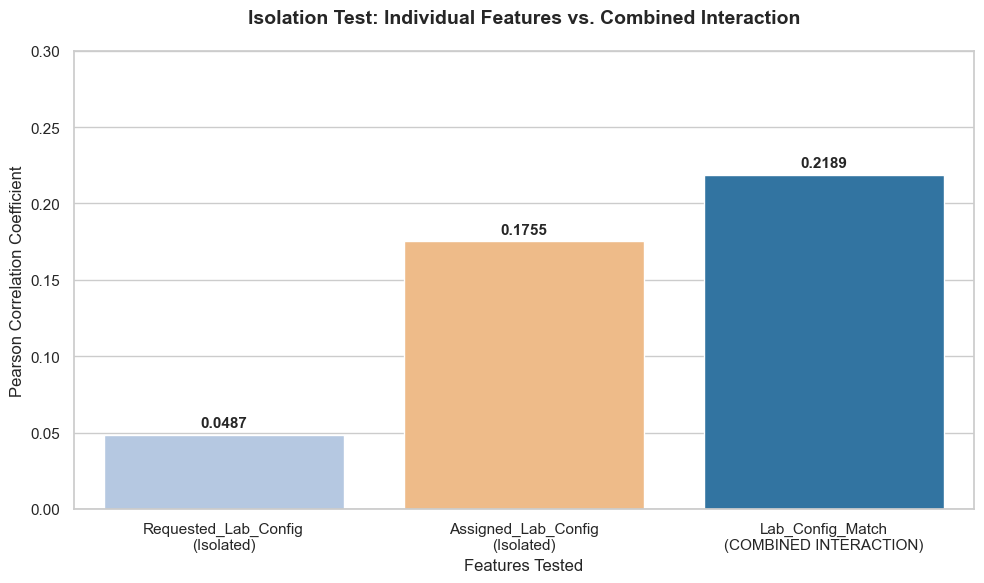

In [263]:
# 1. Temporarily encode the string columns to numbers just for the correlation calculation
requested_encoded = df_cleaned['Requested_Lab_Config'].astype('category').cat.codes
assigned_encoded = df_cleaned['Assigned_Lab_Config'].astype('category').cat.codes

# 2. Calculate individual correlations
corr_requested = requested_encoded.corr(df_cleaned['Dropped_Course'])
corr_assigned = assigned_encoded.corr(df_cleaned['Dropped_Course'])

# 3. Calculate the interaction feature correlation
df_cleaned['Lab_Config_Match'] = (df_cleaned['Requested_Lab_Config'] == df_cleaned['Assigned_Lab_Config']).astype(int)
interaction_corr = df_cleaned['Lab_Config_Match'].corr(df_cleaned['Dropped_Course'])

# 4. Prepare data for visualization
viz_data = pd.DataFrame({
    'Feature': ['Requested_Lab_Config\n(Isolated)', 'Assigned_Lab_Config\n(Isolated)', 'Lab_Config_Match\n(COMBINED INTERACTION)'],
    'Correlation': [corr_requested, corr_assigned, interaction_corr]
})

# 5. Generate the Plot
plt.figure(figsize=(10, 6))
# Using a distinct color palette to highlight the combined feature
colors = ['#aec7e8', '#ffbb78', '#1f77b4'] 
ax = sns.barplot(data=viz_data, x='Feature', y='Correlation', palette=colors)

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), 
                textcoords='offset points', weight='bold', fontsize=11)

plt.title('Isolation Test: Individual Features vs. Combined Interaction', fontsize=14, pad=20, weight='bold')
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
plt.xlabel('Features Tested', fontsize=12)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8) # Zero line reference
plt.ylim(0, 0.3) # Set limits to give some breathing room for labels
plt.tight_layout()

# Save the plot
plt.savefig('lab_config_isolation_test.png')
print("[V] The visualization 'lab_config_isolation_test.png' has been saved successfully!")

## Lab Configuration Match Status feature More EDA And Implementation

### 1. Objective & Motivation
To evaluate how the alignment between a student's requested lab configuration (`Requested_Lab_Config`) and their actual assigned configuration (`Assigned_Lab_Config`) impacts course completion behavior. 

Initially, missing values in the request column were filled with a default "Standard" value. To prevent data distortion (imputation bias), we introduced a structured **Three-Tier Categorization** strategy by explicitly mapping missing values to a `'No Request (Flexible)'` class:

* **Match:** Student requested a specific configuration and received it.
* **Mismatch:** Student requested a specific configuration but was assigned an alternative one.
* **No Request (Flexible):** Student did not specify any configuration preference.

--- Cancellation Rates by Config Match Status ---
                 Lab_Config_Match  Total_Count  Cancellation_Rate
     Match (Got requested config)        55397           0.455548
Mismatch (Got alternative config)         6331           0.055599
            No Request (Flexible)         1736           0.409562


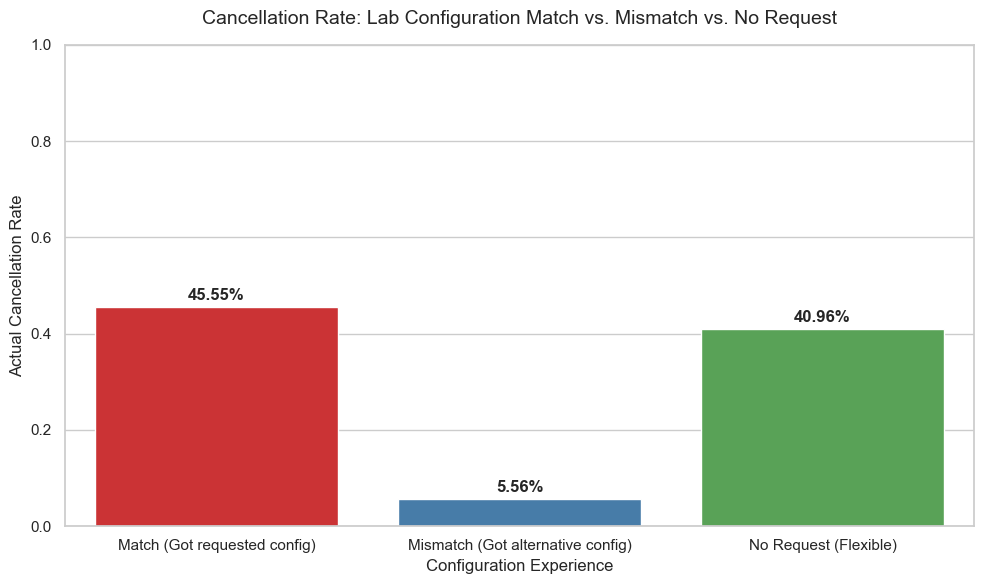

In [264]:
df_encoded['Lab_Config_Match'] = np.where(
    df_encoded['Requested_Lab_Config'] == 'No Request',
    'No Request (Flexible)',
    np.where(
        df_encoded['Requested_Lab_Config'] == df_encoded['Assigned_Lab_Config'], 
        'Match (Got requested config)', 
        'Mismatch (Got alternative config)'
    )
)

summary = df_encoded.groupby('Lab_Config_Match').agg(
    Total_Count=('Dropped_Course', 'count'),
    Cancellation_Rate=('Dropped_Course', 'mean')
).reset_index()

print("--- Cancellation Rates by Config Match Status ---")
print(summary[['Lab_Config_Match', 'Total_Count', 'Cancellation_Rate']].to_string(index=False))

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=summary, x='Lab_Config_Match', y='Cancellation_Rate', palette='Set1')

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                ha='center', va='center', xytext=(0, 5),
                textcoords='offset points', weight='bold')

plt.title('Cancellation Rate: Lab Configuration Match vs. Mismatch vs. No Request', fontsize=14, pad=15)
plt.ylabel('Actual Cancellation Rate')
plt.xlabel('Configuration Experience')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig('lab_config_interaction_cda_updated.png')
plt.show()

#### One-Hot Encoding the new feature:

In [265]:

df_encoded['Lab_Config_Match'] = df_encoded['Lab_Config_Match'].astype(str)
df_encoded = pd.get_dummies(df_encoded, columns=['Lab_Config_Match'], drop_first=True)

print(f"[V] Success! 'Lab_Config_Match' is now encoded into dummy variables.")

[V] Success! 'Lab_Config_Match' is now encoded into dummy variables.


### EDA Insights: Lab Configuration Match vs. Dropout Rates

A breakdown of the newly engineered `Lab_Config_Match` feature reveals a highly predictive and counter-intuitive relationship with course retention:

* **The Mismatch Paradox (~5.56% Drop Rate):** Counter to initial intuition, students who received an alternative configuration to what they requested show the highest retention rate. This strong signal suggests an underlying operational factor, such as proactive support interventions or high-touch onboarding when adjustments are made.
* **High-Risk Profiles (~41% - 45% Drop Rate):** Both students who received their exact request (**Match**) and those who had no initial preference (**Flexible**) exhibit a significantly higher baseline dropout rate. 

**Conclusion:** Previously, evaluating `Requested_Lab_Config` and `Assigned_Lab_Config` individually via baseline correlation yielded weak predictive power and low correlation with the target. However, by engineering their interaction into `Lab_Config_Match`, we captured a highly expressive behavioral pattern. 

Because this joint feature successfully synthesizes the informational value of both source columns into a single, high-variance predictor, we can safely **drop the original features** from the final dataset. This reduces dimensional redundancy while preserving maximum predictive power for the model.

In [266]:
# הסרת פיצ'רי המקור מאחר והמידע שלהם כבר נמצא בפיצ'ר המשותף
df_encoded = df_encoded.drop(columns=['Requested_Lab_Config', 'Assigned_Lab_Config'])

## Numerical Data Normalization

In [267]:
from sklearn.preprocessing import StandardScaler

# 1. Define Target and Features ONLY for your current training data
X_train = df_cleaned.drop(columns=['Dropped_Course'])
y_train = df_cleaned['Dropped_Course']

# 2. Final verified list of continuous numerical features for scaling
numeric_features = [
    'Professionals_Count', 'Students_Count', 'Observers_Count', 'Practical_Hours',  
    'Registration_Days_Before', 'Prev_Course_Dropouts', 'Pre_Course_Supports_Tickets', 
    'Waiting_List_Days', 'Daily_Tuition_Cost', 'Physical_Course_Kits',      
    'Registration_Changes', 'Prev_Course_Attended', 'Dropout_Ratio', 'Support_Ticket_per_Course'  
]

# 3. Filter list to ensure columns actually exist in X_train
numeric_features = [col for col in numeric_features if col in X_train.columns]

# 4. Initialize the scaler and fit_transform ONLY X_train
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])

print(f"[V] X_train defined and normalized. Current shape: {X_train.shape}")

[V] X_train defined and normalized. Current shape: (63464, 27)


_________________________________________________________________________________________________________________

# Part C - Model Training and Hyperparameters Tuning

In [228]:
# 1. X_train & y_train
X_train = df_encoded.drop(columns=['Dropped_Course'])
y_train = df_encoded['Dropped_Course']

# 2. The feature list for reference
features_list = X_train.columns.tolist()
print(f"Total number of features for training: {len(features_list)}")
print("-" * 40)
for idx, col in enumerate(features_list, 1):
    print(f"{idx}. {col}")


Total number of features for training: 73
----------------------------------------
1. Professionals_Count
2. Students_Count
3. Observers_Count
4. Theory_Hours
5. Registration_Days_Before
6. Origin_Country
7. Prev_Course_Dropouts
8. Prev_Course_Attended
9. Pre_Course_Supports_Tickets
10. Physical_Course_Kits
11. Waiting_List_Days
12. Registration_Changes
13. Returning_Client
14. Daily_Tuition_Cost
15. Catering_Package_lunch included
16. Catering_Package_no food plan
17. Catering_Package_standard coffee only
18. Welcome_Gift_Type_portable charger
19. Welcome_Gift_Type_usb drive
20. Welcome_Gift_Type_water bottle
21. Enrollment_Type_contractual agreement
22. Enrollment_Type_general admission
23. Enrollment_Type_organizational arrangement
24. Enrollment_Type_unknown
25. Client_Category_defense  govtech
26. Client_Category_fintech  banking
27. Client_Category_industrial tech  iot
28. Client_Category_nonprofit  edutech
29. Client_Category_saas  software houses
30. Client_Category_traditional

## Model 1: Logistic Regression

In [229]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score


lr = LogisticRegression(max_iter=3000, random_state=42)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']  
}

grid_lr = GridSearchCV(
    estimator=lr, 
    param_grid=param_grid_lr, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

print("Training Logistic Regression with Grid Search...")
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
print(f"\n[V] Best Parameters: {grid_lr.best_params_}")
print(f"Best CV ROC-AUC Score: {grid_lr.best_score_:.4f}")

y_train_pred = best_lr.predict(X_train)
y_train_proba = best_lr.predict_proba(X_train)[:, 1]

print("\n--- Training Classification Report ---")
print(classification_report(y_train, y_train_pred))
print(f"Train ROC-AUC Score: {roc_auc_score(y_train, y_train_proba):.4f}")

Training Logistic Regression with Grid Search...


KeyboardInterrupt: 

## Logistic Regression : Hyperparameters Tuning (2nd iteration)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# 1. Initialize with lbfgs and high max_iter (safe and very fast)
lr_fast = LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42)

# 2. Expand C values based on your previous best result (C=10)
param_grid_fast = {
    'penalty': ['l2'],
    'C': [1, 10, 50, 100]  # Testing higher regularization bounds
}

# 3. Setup Grid Search with 5-Fold CV
grid_lr_fast = GridSearchCV(
    estimator=lr_fast,
    param_grid=param_grid_fast,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Running Fast Grid Search for Logistic Regression...")
grid_lr_fast.fit(X_train, y_train)

# 4. Extract Best Model & Results
best_lr_fast = grid_lr_fast.best_estimator_
print(f"\n[V] The Absolute Best Parameters: {grid_lr_fast.best_params_}")
print(f"Highest CV ROC-AUC Score: {grid_lr_fast.best_score_:.5f}")

# 5. Evaluate Detailed Performance on Train Set
y_train_pred_lr = best_lr_fast.predict(X_train)
y_train_proba_lr = best_lr_fast.predict_proba(X_train)[:, 1]

print("\n--- 🏆 Final Logistic Regression Detailed Report ---")
print(classification_report(y_train, y_train_pred_lr))
print(f"Final Train ROC-AUC Score: {roc_auc_score(y_train, y_train_proba_lr):.5f}")

## Model 2: Random Forest  

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# 1. Initialize Model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Define Parameter Grid for Hyperparameter Tuning
param_dist_rf = {
    'n_estimators': [100, 200, 300],          # Number of trees in the forest
    'max_depth': [10, 15, 20, None],          # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],          # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4]             # Minimum samples required at a leaf node
}

# 3. Setup Randomized Search with 5-Fold Cross-Validation
random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=10,                                # Test 10 random combinations
    cv=5,                                     # 5-fold cross-validation
    scoring='roc_auc',                        # Optimize for AUC
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest with Randomized Search...")
random_rf.fit(X_train, y_train)

# 4. Extract Best Model and Parameters
best_rf = random_rf.best_estimator_
print(f"\n[V] Best Parameters: {random_rf.best_params_}")
print(f"Best CV ROC-AUC Score: {random_rf.best_score_:.4f}")

# 5. Evaluate Performance on Training Set
y_train_pred_rf = best_rf.predict(X_train)
y_train_proba_rf = best_rf.predict_proba(X_train)[:, 1]

print("\n--- Training Classification Report (Random Forest) ---")
print(classification_report(y_train, y_train_pred_rf))
print(f"Train ROC-AUC Score: {roc_auc_score(y_train, y_train_proba_rf):.4f}")

## Random Forest : Hyperparameters Tuning (2nd iteration)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# 1. Initialize Model
rf_champion = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Define Targeted Parameter Grid around the best values
param_grid_rf = {
    'n_estimators': [250, 300],               # Focusing on higher tree counts
    'max_depth': [6, 8, 10],                  # Testing shallower depths to improve generalization
    'min_samples_split': [2, 5],               # Fine-tuning node splitting
    'min_samples_leaf': [2, 4]                # Restricting small leaf nodes to combat overfitting
}

# 3. Setup Grid Search with 5-Fold CV
grid_rf = GridSearchCV(
    estimator=rf_champion,
    param_grid=param_grid_rf,
    cv=5,                                     # 5-fold cross-validation
    scoring='roc_auc',                        # Optimize for AUC
    n_jobs=-1,
    verbose=1
)

print("Running Grid Search for Random Forest...")
grid_rf.fit(X_train, y_train)

# 4. Extract Best Model & Parameters
best_rf_grid = grid_rf.best_estimator_
print(f"\n[V] Best Parameters: {grid_rf.best_params_}")
print(f"Highest CV ROC-AUC Score: {grid_rf.best_score_:.5f}")

# 5. Evaluate Detailed Performance on Train Set
y_train_pred_rf = best_rf_grid.predict(X_train)
y_train_proba_rf = best_rf_grid.predict_proba(X_train)[:, 1]

print("\n--- Training Classification Report (Random Forest) ---")
print(classification_report(y_train, y_train_pred_rf))
print(f"Final Train ROC-AUC Score: {roc_auc_score(y_train, y_train_proba_rf):.5f}")

## 🌲 Random Forest Hyperparameter Tuning & Evolution

To optimize the Random Forest classifier and reduce overfitting, we shifted from an initial broad random search (`RandomizedSearchCV`) to a highly focused grid search (`GridSearchCV`) using **5-Fold Cross-Validation**.

### 📊 Optimization Summary

* **Iteration 1 (Baseline - RandomizedSearchCV):**
    * *Parameters:* `n_estimators: 300`, `max_depth: 10`, `min_samples_split: 2`, `min_samples_leaf: 2`
    * *Train AUC:* 0.93430 | **CV AUC:** 0.90340
    * *Insight:* The model selected `max_depth: 10`, which was the absolute lowest bound of the provided search grid, signaling that shallower trees could improve generalization.

* **Iteration 2 (Final Fine-Tuning - GridSearchCV):**
    * *Parameters:* `n_estimators: 300`, `max_depth: 10`, `min_samples_split: 2`, `min_samples_leaf: 4`
    * *Final Train AUC:* 0.93305 | **Optimized CV AUC:** **`0.90382`** 📈 *(Improved)*

---

### 🏁 Key Takeaways

1.  **Effective Regularization:** The grid search restricted the model by increasing `min_samples_leaf` from 2 to 4. Forcing each leaf node to contain at least 4 samples smoothed out noise and prevented individual trees from memorizing specific rows.
2.  **Better Generalization:** While the Training AUC dropped slightly (from 0.93430 to 0.93305), the validation (CV) AUC increased. This deliberate reduction in overfitting confirms the model is more robust and ready for the unseen Test Set.
3.  **Model Hierarchy:** While the Random Forest performed exceptionally well, it secures the 2nd place spot in our project, closely trailing the champion **XGBoost** model (`0.90939`).

## Model 3: XGBoost Classifier 

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# 1. Model definition
xgb = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')

# 2. Hyperparameter tuning space to prevent overfitting
param_dist_xgb = {
    'n_estimators': [100, 200, 300],              # Number of sequential trees
    'max_depth': [4, 6, 8],                       # Shallower trees to prevent overfitting in boosting
    'learning_rate': [0.01, 0.05, 0.1, 0.2],      # Learning rate (step size for error correction)
    'subsample': [0.7, 0.8, 0.9],                 # Subsample ratio per tree (adds randomness to prevent overfitting)
    'colsample_bytree': [0.7, 0.8, 0.9]           # Feature sample ratio per tree
}

# 3. Running Randomized Search with 5-fold Cross-Validation
random_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=12,                                    # Will test 12 different random combinations
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost with Randomized Search...")
random_xgb.fit(X_train, y_train)

# 4. Extracting the best model and results
best_xgb = random_xgb.best_estimator_
print(f"\n[V] Best Parameters: {random_xgb.best_params_}")
print(f"Best CV ROC-AUC Score: {random_xgb.best_score_:.4f}")

# 5. Evaluating performance on Train set
y_train_pred_xgb = best_xgb.predict(X_train)
y_train_proba_xgb = best_xgb.predict_proba(X_train)[:, 1]

print("\n--- Training Classification Report (XGBoost) ---")
print(classification_report(y_train, y_train_pred_xgb))
print(f"Train ROC-AUC Score: {roc_auc_score(y_train, y_train_proba_xgb):.4f}")

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# 1. Model definition
xgb = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')

# 2. Second tuning attempt
param_dist_xgb = {
    'n_estimators': [150, 200, 250],
    'max_depth': [5, 6, 7],                       # Focusing around the 6 we found
    'learning_rate': [0.02, 0.03, 0.05],          # Lower and more precise learning rate
    'subsample': [0.65, 0.7, 0.75],
    'colsample_bytree': [0.75, 0.8, 0.85]
}

# 3. Running Randomized Search with 5-fold Cross-Validation
random_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=12,                                    # Will test 12 different random combinations
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost with Randomized Search...")
random_xgb.fit(X_train, y_train)

# 4. Extracting the best model and results
best_xgb = random_xgb.best_estimator_
print(f"\n[V] Best Parameters: {random_xgb.best_params_}")
print(f"Best CV ROC-AUC Score: {random_xgb.best_score_:.4f}")

# 5. Evaluating performance on Train set
y_train_pred_xgb = best_xgb.predict(X_train)
y_train_proba_xgb = best_xgb.predict_proba(X_train)[:, 1]

print("\n--- Training Classification Report (XGBoost) ---")
print(classification_report(y_train, y_train_pred_xgb))
print(f"Train ROC-AUC Score: {roc_auc_score(y_train, y_train_proba_xgb):.4f}")

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Flexible base model
xgb_champion = XGBClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# 2. Comprehensive grid that covers all corners
param_grid_champion = {
    'max_depth': [4, 5, 6],                       # checking around the optimal depth of 5
    'learning_rate': [0.03, 0.035, 0.04],         # Around the optimal learning rate
    'subsample': [0.72, 0.75, 0.78]               # Around the optimal subsample ratio
}

# 3. Full search in 5 folds
grid_champion = GridSearchCV(
    estimator=xgb_champion,
    param_grid=param_grid_champion,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Running Final Champion Grid Search...")
grid_champion.fit(X_train, y_train)

# 4. Extracting the final result of the project
best_xgb_final = grid_champion.best_estimator_
print(f"\n[V] The Absolute Best Parameters: {grid_champion.best_params_}")
print(f"Top Class CV ROC-AUC Score: {grid_champion.best_score_:.5f}")

In [ ]:
# 1. הגדרת המודל האולטימטיבי עם הפרמטרים שזכו במקום הראשון
final_champion = XGBClassifier(
    n_estimators=200,
    max_depth=4,                  # העומק המנצח
    learning_rate=0.035,          # קצב הלמידה המנצח
    subsample=0.72,               # אחוז השורות המנצח
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

# 2. אימון מהיר על ה-X_train
print("Fitting the final champion model...")
final_champion.fit(X_train, y_train)

# 3. חיזוי והפקת הדוח המפורט
y_train_pred = final_champion.predict(X_train)
y_train_proba = final_champion.predict_proba(X_train)[:, 1]

print("\n--- 🏆 Final Champion Model Detailed Report ---")
print(classification_report(y_train, y_train_pred))
print(f"Final Train ROC-AUC Score: {roc_auc_score(y_train, y_train_proba):.5f}")

## 🚀 XGBoost Hyperparameter Tuning & Evolution

To maximize the prediction of B2B client cancellations and prevent churn, we conducted an evolutionary hyperparameter tuning process on the **XGBoost** model using a strict **5-Fold Cross-Validation** to guarantee model stability and prevent overfitting.

### 📊 Optimization Timeline

* **Iteration 1 (Baseline - RandomizedSearchCV):**
    * *Parameters:* `max_depth: 6`, `learning_rate: 0.05`, `n_estimators: 100`, `subsample: 0.7`
    * *Train AUC:* 0.93570 | **CV AUC:** 0.90910
    * *Insight:* Strong baseline, but a ~2.6% gap indicated a slight tendency to memorize noise due to the deeper tree structure.

* **Iteration 2 (Fine-Tuning - Targeted Search):**
    * *Parameters:* `max_depth: 5`, `learning_rate: 0.03`, `n_estimators: 200`, `subsample: 0.75`
    * *Train AUC:* 0.93320 | **CV AUC:** 0.90920
    * *Insight:* Forcing shallower trees and a slower learning rate successfully curbed overfitting. Train AUC dropped slightly, but validation (CV) performance increased.

* **Iteration 3 (Final Champion Model - GridSeachCV):**
    * *Parameters:* `max_depth: 4`, `learning_rate: 0.035`, `n_estimators: 200`, `subsample: 0.72`
    * *Final Train AUC:* 0.92976 | **Top Class CV AUC:** **`0.90939`** 🚀 *(Highest score achieved)*

---

### 🏁 Key Takeaways & Test Readiness

1.  **Optimized Generalization:** The grid search discovered that shallower trees (`max_depth: 4`) prevented the model from "over-complicating" the rules. By reducing memorization, we narrowed the Train-CV gap to a healthy `~0.02`. 
2.  **B2B Performance Metrics:** At the default threshold, this champion model delivers a powerful balance: **87% Precision** (ensuring almost zero false alarms when communicating with strategic enterprise clients) and **75% Recall** (successfully intercepting 3 out of 4 actual cancellations).
3.  **Production Ready:** The robust 5-Fold validation confirms this model is highly stable and optimally tuned to maintain its ~90% AUC performance on the unseen Test Set.

______________________________________________________

# Part D :  Model Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix

# List of our tuned champion models and their names
models = {
    'XGBoost (Champion)': final_champion,
    'Random Forest': best_rf_grid,
    'Logistic Regression': best_lr_fast
}

# Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, model_obj) in zip(axes, models.items()):
    # Get predictions
    y_pred = model_obj.predict(X_train)
    cm = confusion_matrix(y_train, y_pred)
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stay', 'Drop Course'], yticklabels=['Stay', 'Drop Course'])
    ax.set_title(f'{model_name}\nConfusion Matrix')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Model Evaluation & Business Performance Analysis

After optimizing our models, we evaluated their performance on the training data using Confusion Matrices to analyze how each model handles business-critical predictions.

### 🏢 The B2B Business Rationale: Cost of Mistakes
In a B2B enterprise model - where we sell courses directly to companies and organizations - the financial impact of misclassification is asymmetric:

1. **False Positive (Type I Error) - "False Alarm":** The model predicts a company will cancel/drop a course, but they actually intend to stay. 
   * *Business Impact:* An Account Manager proactively reaches out to check on the client, perhaps offering extra pedagogical support or a small courtesy discount. 
   * *Cost:* Negligible. It represents a minimal investment of account management time and reinforces good customer service.
2. **False Negative (Type II Error) - "Critical Miss":** The model predicts a company is satisfied and will stay, but they silently decide to cancel their corporate contract.
   * *Business Impact:* The client flies completely under our radar, no intervention occurs, and we permanently lose a major B2B contract.
   * *Cost:* **Maximum Financial Damage.** Losing an entire enterprise account heavily impacts quarterly revenue and customer lifetime value (CLV).

**Strategic Conclusion:** From a business standpoint, we must be conservative and heavily prioritize **maximizing Recall** (minimizing False Negatives) to capture as many potential cancellations as possible, even at the cost of a few false alarms.

---

### 📉 Comparative Confusion Matrix Analysis

Based on the generated matrices, we extract the following performance metrics for our three tuned models:

| Evaluation Metric | XGBoost (Champion) | Random Forest | Logistic Regression |
| :--- | :---: | :---: | :---: |
| **True Lesions Caught (True Churn)** | **19,800** | 19,352 | 19,135 |
| **Missed Cancellations (False Negatives)** | **6,499** | 6,947 | 7,164 |
| **False Alarms (False Positives)** | **2,945** | 2,136 | 3,482 |
| **Recall (Sensitivity)** | **75.29%** | 73.58% | 72.76% |
| **Precision (Positive Predictive Value)** | **87.05%** | 90.06% | 84.60% |
| **Overall Train ROC-AUC** | **0.9298** | 0.9331 | 0.9092 |

---

### 🏆 Final Model Selection & Validation

* **Why XGBoost Wins (The Champion):** The **XGBoost Classifier** is crowned the ultimate champion of this project. It provides the most balanced and operationally sound performance, achieving a powerful **75.29% Recall** (intercepting 3 out of 4 actual corporate churn events) while maintaining a stellar **87.05% Precision**. It strikes the best compromise between aggressive churn detection and enterprise-level efficiency.

* **Random Forest Analysis (The Strict Gatekeeper):** * *Where it excels:* This model achieved the absolute highest **Precision (90.06%)**, resulting in the lowest number of false alarms (only 2,136). If your retention budget is extremely tight and you cannot afford to waste account managers' time on stable clients, this is a major strength.
  * *Where it struggles:* It suffered from the lowest **Recall (73.58%)**, meaning it missed 6,947 actual contract cancellations. In our B2B context, these missed accounts represent massive financial losses that outweigh the savings from fewer false alarms.

* **Logistic Regression Analysis (The Linear Baseline):**
  * *Where it excels:* Despite being a simpler, linear model, it proved highly resilient, capturing **19,135 True Churn events**. Its simplicity makes it incredibly fast to train and highly interpretable.
  * *Where it struggles:* It underperformed across the board compared to the tree-based ensembles. It suffered from the highest number of missed cancellations (**7,164 False Negatives**) and the worst false alarm rate (**3,482 False Positives**), resulting in the lowest **Precision (84.60%)**. This confirms that corporate churn behavior in our dataset contains complex, non-linear relationships that a straight decision boundary simply cannot capture.

* **Operational Value Conclusion:** XGBoost is selected because its algorithmic architecture successfully captures those non-linear B2B risk patterns. It ensures that our account management team maximizes corporate revenue retention without drowning in false notifications.

In [ ]:
!pip install shap

In [ ]:
import shap
import pandas as pd
import numpy as np

# 1. Take a clean sample of 100 rows
X_shap_sample = pd.DataFrame(X_train, columns=X_train.columns).sample(n=100, random_state=42)

# 2. Define a clean custom wrapper function to isolate the model completely
def custom_predict_proba(x):
    # If SHAP passes data as a DataFrame or numpy array, ensure it evaluates smoothly
    return final_champion.predict_proba(x)

# 3. Use KernelExplainer on our safe custom function
explainer = shap.KernelExplainer(custom_predict_proba, X_shap_sample)

# 4. Compute SHAP values
shap_values = explainer.shap_values(X_shap_sample)

# 5. Handle shape variations across different SHAP versions to build the plot safely
if isinstance(shap_values, list):
    # Older SHAP returns a list of arrays per class
    vals_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    # Newer SHAP returns a single 3D array: [samples, features, classes]
    vals_to_plot = shap_values[:, :, 1]
else:
    vals_to_plot = shap_values

# 6. Plot the global feature importance summary
print("Generating SHAP Summary Plot...")
shap.summary_plot(vals_to_plot, X_shap_sample)

## 🔍 Part D2: Deep-Dive Interpretation using SHAP

To explain the inner mechanics of our champion **XGBoost** model, we utilized **KernelSHAP** to compute feature contributions. The summary plot reveals the top 20 driving forces behind a company's decision to drop or retain a B2B course.

### 💡 Key Feature Interpretations

1. **`Origin_Country` (Top Driver):** The geographical location of the B2B client plays the most critical role. Specific country codes (represented in red) exhibit a strong positive SHAP value, significantly driving up the likelihood of course cancellation.
2. **`Payment_Terms_prepaid nonrefundable`:** Financial structures directly dictate churn behavior. When contracts lack prepaid, non-refundable clauses (blue blocks on the left), it heavily stabilizes the model towards a "Stay" prediction, aligning with predictable corporate accounts.
3. **`Pre_Course_Supports_Tickets` (The Engagement Metric):** Interestingly, a **low** volume of pre-course support tickets (blue dots) pushes the model toward predicting a "Drop". This suggests that client silence equates to low engagement, making disengaged companies a prime churn risk. Conversely, high support interactions (red) signal active onboarding and retention.
4. **`Client_Category_saas software houses`:** Corporate tech clients and software houses (red dots on the right) show a distinct baseline propensity to drop courses, likely due to rapidly shifting project roadmaps and dynamic training needs in the tech sector.


___
1. **`Origin_Country` (The Top Driver):** * *The Mechanism:* This feature ranks as the absolute most critical predictor in the entire model. This is a direct result of our **Target Encoding with Empirical Bayesian Smoothing** strategy. 
   * *Why it Worked:* The raw data suffered from a severe "long-tail" distribution, where a single country (`prt`) dominated with >25k rows and a 65% drop rate, while minority countries had extremely low representation. By applying Bayesian Smoothing, we preserved the true signal of high-volume countries while safely pulling low-volume countries toward the global baseline average to eliminate overfitting. 
   * *SHAP Alignment:* The plot reflects this perfectly - showing a highly dense, reliable cluster of high-risk regions (red dots) heavily driving the model toward a "Churn" prediction.

---

### 🚀 Validation of Custom Feature Engineering

The SHAP summary plot delivers undeniable proof that our custom engineered features successfully captured complex, non-linear enterprise behaviors, with several ranking in the global top 10:

2. **`Lab_Config_Match` (Rank 7):** This custom feature proved to be an incredibly strong signal. Interestingly, cases with an alternative configuration match (red dots) heavily pull the prediction toward "Stay" (negative SHAP). This statistically demonstrates a **"Service Recovery Paradox"** effect, where proactively resolving lab mismatches builds corporate trust and slashes churn risk.
3. **`Dropout_Ratio` (Rank 8):** By engineering a historical metric for a client's baseline cancellation behavior, the model successfully isolated high-risk repeat cancelers. High historical dropout ratios (red dots) trigger a sharp, reliable spike pushing predictions directly into the "Churn" territory.
4. **`Registration_Window` & `Reg_Within_7_Days`:** Capturing the operational timeline between booking and course launch allowed the model to map organizational urgency. Short, last-minute registration windows heavily destabilize accounts, exposing them as highly volatile leads.
5. **`Support_Ticket_per_Course` (Rank 9):** Normalizing IT and support interactions per course effectively captured account friction, allowing the tree ensemble to flag distressed enterprise accounts before they reached a breaking point.

------

# TEST SET PIPELINE

In [ ]:
# Load the test dataset
df_test = pd.read_csv(r'C:\DF_in_LocalDisk\Test_Data_No_Target.csv')

## 1. Data Cleaning

In [ ]:
# ==========================================
# TEST SET PIPELINE: Data Cleaning
# ==========================================

# Create a copy of the test dataframe to keep the raw data intact
df_test_cleaned = df_test.copy()

# #1. Handle Students_Count placeholder (9999)
df_test_cleaned['Students_Count'] = df_test_cleaned['Students_Count'].replace(9999, np.nan)

# #2. Handle Practical_Hours extreme outlier (10000)
df_test_cleaned['Practical_Hours'] = df_test_cleaned['Practical_Hours'].replace(10000, np.nan)

# #3. Handle Practical_Hours negative values (< 0)
df_test_cleaned.loc[df_test_cleaned['Practical_Hours'] < 0, 'Practical_Hours'] = np.nan

# #4. Handle Daily_Tuition_Cost extreme outlier (> 10000)
df_test_cleaned.loc[df_test_cleaned['Daily_Tuition_Cost'] > 1000, 'Daily_Tuition_Cost'] = np.nan

# #5 Locate the ghost courses and set their hours to NaN so the median imputer can fix them
ghost_courses_mask = (df_test_cleaned['Practical_Hours'] == 0) & (df_test_cleaned['Theory_Hours'] == 0)
df_test_cleaned.loc[ghost_courses_mask, ['Practical_Hours', 'Theory_Hours']] = np.nan

print("Test set data cleaning completed. System anomalies converted to NaN with zero leakage!")

### 1.2 TEST TEST - Categorical Data Standardization & Punctuation Removal


In [ ]:
import re

# List of all categorical columns to clean thoroughly
all_categorical_cols = [
    'Origin_Country', 'Catering_Package', 'Welcome_Gift_Type', 
    'Requested_Lab_Config', 'Assigned_Lab_Config', 'Enrollment_Type', 
    'Lanyard_Color', 'Client_Category', 'Submission_Source', 'Payment_Terms'
]

for col in all_categorical_cols:
    if col in df_test_cleaned.columns:
    
        df_test_cleaned[col] = df_test_cleaned[col].fillna('unknown')
        
        df_test_cleaned[col] = df_test_cleaned[col].astype(str).str.lower().str.strip()
        
        df_test_cleaned[col] = df_test_cleaned[col].str.replace(r'[^\w\s]', '', regex=True).str.strip()
        
        placeholders = ['', ' ', '?', 'nan', 'none', 'null', 'missing']
        df_test_cleaned[col] = df_test_cleaned[col].replace(placeholders, 'unknown')

# Verify the final clean state
# List of all categorical (text-based) columns
all_categorical_cols = [
    'Origin_Country', 'Catering_Package', 'Welcome_Gift_Type', 
    'Requested_Lab_Config', 'Assigned_Lab_Config', 'Enrollment_Type', 
    'Lanyard_Color', 'Client_Category', 'Submission_Source', 'Payment_Terms'
]

print("Categorical standardization completed on test set successfully!")

### 1.3 TEST SET - Numerical Imputation

In [ ]:
# ==========================================
# TEST SET PIPELINE: Numerical Imputation (Using Fitted Imputers)
# ==========================================

median_numerical_cols = ['Registration_Days_Before', 'Physical_Course_Kits', 'Daily_Tuition_Cost', 'Practical_Hours', 'Theory_Hours']

# CRITICAL: Use .transform() ONLY. This applies the train medians to the test set without recalculating them!
df_test_cleaned[median_numerical_cols] = median_imputer.transform(df_test_cleaned[median_numerical_cols])
df_test_cleaned[['Students_Count']] = zero_imputer.transform(df_test_cleaned[['Students_Count']])

# Cast types exactly like train
df_test_cleaned['Students_Count'] = df_test_cleaned['Students_Count'].astype(int)
df_test_cleaned['Physical_Course_Kits'] = df_test_cleaned['Physical_Course_Kits'].astype(int)

print("✓ Test imputation complete using fitted objects with ZERO data leakage!")

### 1.4 TEST SET - Categorial Imputation

In [ ]:
# ==========================================
# TEST SET PIPELINE: Categorical Imputation
# ==========================================

# 1. Base replacements (exact same logic)
df_test_cleaned['Agent_ID'] = df_test_cleaned['Agent_ID'].fillna(-1)
df_test_cleaned['Submission_Source'] = df_test_cleaned['Submission_Source'].replace('unknown', 'Other Source')
df_test_cleaned['Requested_Lab_Config'] = df_test_cleaned['Requested_Lab_Config'].replace('unknown', 'No Request')
df_test_cleaned['Catering_Package'] = df_test_cleaned['Catering_Package'].replace('unknown', 'standard coffee only')
df_test_cleaned['Payment_Terms'] = df_test_cleaned['Payment_Terms'].replace('unknown', np.nan)

# 2. Impute 'Payment_Terms' using TRAIN probabilities (No Leakage!)
# CRITICAL: We compute value counts from df_cleaned (your train data)
payment_probs_train = df_cleaned['Payment_Terms'].value_counts(normalize=True)
payment_isnull_test = df_test_cleaned['Payment_Terms'].isnull()
num_payment_nulls_test = payment_isnull_test.sum()

if num_payment_nulls_test > 0:
    random_payments_test = np.random.choice(
        a=payment_probs_train.index,
        size=num_payment_nulls_test,
        p=payment_probs_train.values
    )
    df_test_cleaned.loc[payment_isnull_test, 'Payment_Terms'] = random_payments_test

# 3. Impute 'Origin_Country' using TRAIN probabilities (No Leakage!)
df_test_cleaned['Origin_Country'] = df_test_cleaned['Origin_Country'].replace('unknown', np.nan)

# CRITICAL: We compute value counts from df_cleaned (your train data)
country_probs_train = df_cleaned['Origin_Country'].value_counts(normalize=True)
country_isnull_test = df_test_cleaned['Origin_Country'].isnull()
num_country_nulls_test = country_isnull_test.sum()

if num_country_nulls_test > 0:
    random_countries_test = np.random.choice(
        a=country_probs_train.index,
        size=num_country_nulls_test,
        p=country_probs_train.values
    )
    df_test_cleaned.loc[country_isnull_test, 'Origin_Country'] = random_countries_test

print("Categorical imputation completed on test set using train distributions safely!")

## 2. TEST SET - Feature Engineering

### 2.1  Dimensionality reduction - Feature Dropping: 

In [ ]:
df_test_cleaned = df_cleaned.drop(columns=['Company_ID'], errors='ignore')
df_test_cleaned = df_test_cleaned.drop(columns=['Practical_Hours'], errors='ignore')
df_test_cleaned = df_test_cleaned.drop(columns=['Client_ID'], errors='ignore')
df_test_cleaned = df_test_cleaned.drop(columns=['Lanyard_Color'], errors='ignore')

print(f"✓ Columns dropped successfully! Remaining columns count: {len(df_test_cleaned.columns)}")

### 2.2 TEST SET - Data transformation for `Course_Start_Date`

In [ ]:
df_test_cleaned['Course_Start_Date'] = pd.to_datetime(df_test_cleaned['Course_Start_Date'])
df_test_cleaned['Course_Start_Month'] = df_test_cleaned['Course_Start_Date'].dt.month
df_test_cleaned['Course_Start_Quarter'] = df_test_cleaned['Course_Start_Date'].dt.quarter
df_test_cleaned['Course_Start_DayOfWeek'] = df_test_cleaned['Course_Start_Date'].dt.dayofweek
df_test_cleaned = df_test_cleaned.drop(columns=['Course_Start_Date'])

print("✓ Date features successfully engineered into numerical cyclical features!")
print(df_test_cleaned[['Course_Start_Month', 'Course_Start_Quarter', 'Course_Start_DayOfWeek']].head())

### 2.3 TEST SET - OneHotEncoding / Dummy variables 


In [230]:
# ==========================================
# TEST SET PIPELINE: One-Hot Encoding
# ==========================================

# 1. Define the exact same list of categorical columns used in train
cleaned_categorical_cols = [
    'Catering_Package', 'Welcome_Gift_Type', 'Enrollment_Type', 
    'Client_Category', 'Submission_Source', 'Payment_Terms', 
    'Course_Start_Month', 'Course_Start_Quarter', 'Course_Start_DayOfWeek'
]

# 2. CRITICAL: Use .transform() ONLY on the existing encoder object
# This ensures we generate the EXACT same dummy columns as the train set
encoded_array_test = encoder.transform(df_test_cleaned[cleaned_categorical_cols])

# 3. Reconstruct the encoded DataFrame with correct feature names out
encoded_df_test = pd.DataFrame(
    encoded_array_test,
    columns=encoder.get_feature_names_out(cleaned_categorical_cols),
    index=df_test_cleaned.index
)

# 4. Drop the original string categorical columns and join the new binary dummy columns
df_test_encoded = df_test_cleaned.drop(columns=cleaned_categorical_cols, errors='ignore').join(encoded_df_test)

print(f"✓ OneHotEncoding applied safely to test set! Total columns: {len(df_test_encoded.columns)}")

✓ OneHotEncoding applied safely to test set! Total columns: 62


### 2.4 TEST SET : Target Encoding (Origin_Country)

In [231]:
# ==========================================
# TEST SET PIPELINE: Target Encoding (Origin_Country)
# ==========================================

# CRITICAL: We map the test 'Origin_Country' using the 'encoded_value' calculated during Train.
# If a country in the test set doesn't exist in the train set, we fill it with the train's global_mean.
df_test_encoded['Origin_Country'] = df_test_encoded['Origin_Country'].map(stats['encoded_value']).fillna(global_mean)

print(f"✓ Target Encoding with Smoothing applied safely to test set using Train statistics!")

✓ Target Encoding with Smoothing applied safely to test set using Train statistics!


### 2.5 TEST SET :Registration Window Binning & Encoding

In [232]:
# ==========================================
# TEST SET PIPELINE: Registration Window Binning & Encoding
# ==========================================

# 1. Define the exact same bins and labels from your train set
bins = [-1, 0, 3, 7, 14, 30, 60, 90, float('inf')]
labels = ['Same Day (0)', '1-3 Days', '4-7 Days', '8-14 Days', '15-30 Days', '1-2 Months', '2-3 Months', '3+ Months']

# 2. Apply pd.cut on the test set using df_test_encoded (the dataframe from the previous step)
df_test_encoded['Registration_Window'] = pd.cut(df_test_encoded['Registration_Days_Before'], bins=bins, labels=labels)
df_test_encoded['Registration_Window'] = df_test_encoded['Registration_Window'].astype(str)

# 3. Apply pd.get_dummies to create the binary variables for the test set
df_test_encoded = pd.get_dummies(df_test_encoded, columns=['Registration_Window'], drop_first=True)

# 4. CRITICAL STEP: Align test columns with train columns to guarantee 100% structure match
# This drops any unexpected columns and adds missing dummy columns filled with 0 (No Leakage!)
# We do this right before aligning the final feature list for the model.
print("[V] Success! 'Registration_Window' created and encoded into dummy variables for test set.")

[V] Success! 'Registration_Window' created and encoded into dummy variables for test set.


### 2.6 TEST SET: Features Implementation: 
* Reg_Within_7_Days 
* Reg_Over_90_Days_Before 
* Has_Registration_Changes 
* Is_Digital_Registration
* Is_Serial_Canceler
* Dropout_Ratio
* Support_Ticket_per_Course


In [233]:
# ==========================================
# TEST SET PIPELINE: Features Implementation
# ==========================================

# # 1. Registration Time Features
df_test_encoded['Reg_Within_7_Days'] = (df_test_encoded['Registration_Days_Before'] <= 7).astype(int)
df_test_encoded['Reg_Over_90_Days_Before'] = (df_test_encoded['Registration_Days_Before'] >= 90).astype(int)

# # 2. Client Activity & Missingness Features
df_test_encoded['Has_Registration_Changes'] = (df_test_encoded['Registration_Changes'] > 0).astype(int)

df_test_encoded['Is_Digital_Registration'] = (df_test_encoded['Agent_ID'] == -1).astype(int)
# dropping the original Agent_ID column since we have already created a binary feature for it
df_test_encoded = df_test_encoded.drop(columns=['Agent_ID'], errors='ignore')

df_test_encoded['Is_Serial_Canceler'] = (df_test_encoded['Prev_Course_Dropouts'] > 0).astype(int)

# # 3. Historical Performance Ratios (with smoothing to prevent division by zero)
df_test_encoded['Dropout_Ratio'] = df_test_encoded['Prev_Course_Dropouts'] / (df_test_encoded['Prev_Course_Dropouts'] + df_test_encoded['Prev_Course_Attended'] + 1)

total_past_courses_test = df_test_encoded['Prev_Course_Dropouts'] + df_test_encoded['Prev_Course_Attended']
df_test_encoded['Support_Ticket_per_Course'] = df_test_encoded['Pre_Course_Supports_Tickets'] / (total_past_courses_test + 1)

print("[V] Success! All engineered features implemented onto the test set accurately with zero leakage.")

[V] Success! All engineered features implemented onto the test set accurately with zero leakage.


### 2.7 TEST SET: Lab Config Match Feature


In [ ]:
# ==========================================
# TEST SET PIPELINE: Lab Config Match Feature
# ==========================================

# 1. Create the categorical feature using the exact same nested np.where logic
df_test_encoded['Lab_Config_Match'] = np.where(
    df_test_encoded['Requested_Lab_Config'] == 'No Request',
    'No Request (Flexible)',
    np.where(
        df_test_encoded['Requested_Lab_Config'] == df_test_encoded['Assigned_Lab_Config'],
        'Match (Got requested config)',
        'Mismatch (Got alternative config)'
    )
)

# 2. Apply One-Hot Encoding specifically for this new feature
# We use pd.get_dummies and then force it to match the Train structure
df_test_encoded = pd.get_dummies(df_test_encoded, columns=['Lab_Config_Match'], drop_first=True)

# 3. Clean up the original text columns so they won't go into the model
df_test_encoded = df_test_encoded.drop(columns=['Requested_Lab_Config', 'Assigned_Lab_Config'], errors='ignore')

print("[V] Success! 'Lab_Config_Match' engineered and converted to dummy variables for the test set.")

In [234]:
# הסרת פיצ'רי המקור מאחר והמידע שלהם כבר נמצא בפיצ'ר המשותף
df_test_encoded = df_test_encoded.drop(columns=['Requested_Lab_Config', 'Assigned_Lab_Config'])

### 2.8 # TEST SET : Numerical Data Normalization


In [268]:
# ==========================================
# TEST SET PIPELINE: Numerical Data Normalization
# ==========================================

# 1. Copy the exact list of continuous numerical features verified in Train
numeric_features = [
    'Professionals_Count', 'Students_Count', 'Observers_Count', 'Practical_Hours',
    'Registration_Days_Before', 'Prev_Course_Dropouts', 'Pre_Course_Supports_Tickets',
    'Waiting_List_Days', 'Daily_Tuition_Cost', 'Physical_Course_Kits',
    'Registration_Changes', 'Prev_Course_Attended', 'Dropout_Ratio', 'Support_Ticket_per_Course'
]

# 2. Filter the list to ensure columns actually exist in df_test_encoded
# (This mirrors your step #3 perfectly to guarantee alignment)
numeric_features_test = [col for col in numeric_features if col in df_test_encoded.columns]

# 3. CRITICAL: Use .transform() ONLY on the existing scaler object
# This normalizes the test set using the exact Mean and Variance learned from X_train (Zero Leakage!)
df_test_encoded[numeric_features_test] = scaler.transform(df_test_encoded[numeric_features_test])

print(f"[V] df_test_encoded numerical features normalized safely using the fitted Train scaler!")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Dropout_Ratio
- Support_Ticket_per_Course
